# Phase 2 · 11단원 — 앙상블 방법

> **불완전한 모델 여럿을 모으면, 그중 어느 하나보다 나은 것이 나옵니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/11-ensemble-methods>
- 예상 시간: 90분 · 선수 지식: Phase 2 1~10단원 (특히 4단원 트리, 10단원 편향-분산)

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **결정 스텀프**(깊이 1 트리)를 만들고, 그걸 기반으로 **AdaBoost**를 밑바닥부터 구현합니다.
2. **그래디언트 부스팅**을 잔차 적합으로 구현하고, sklearn·XGBoost와 대조합니다.
3. **배깅 vs 부스팅**이 편향-분산에 각각 어떻게 작용하는지 확인합니다.
4. **스태킹**을 누출 없이(교차검증으로) 만들고, 기반 모델 각각과 비교합니다.

### 🔑 10단원과 짝입니다

10단원 8절에서 **배깅이 분산을 줄이는** 걸 봤습니다. 그런데 **부스팅은 안 만들어 봤죠.**

| | 배깅 | 부스팅 |
| --- | --- | --- |
| 학습 방식 | **동시에** (독립) | **순서대로** (앞의 실수를 보고) |
| 주 효과 | **분산 ↓** | **편향 ↓** |
| 기반 모델 | **분산이 큰** 것 (깊은 트리) | **편향이 큰** 것 (스텀프) |
| 과적합 | 나무를 늘려도 **잘 안 함** | 라운드를 늘리면 **합니다** |
| 이 단원 | 2절 (4단원 7절 복습) | **3~5절 (직접 만듭니다)** |

> 📗 원문: "Bagging reduces variance. Boosting reduces bias. Stacking learns which models
> to trust on which inputs."

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 불완전한 모델을 모으면 | 📗 원문 |
| 1 | 🔑 왜 앙상블이 되나 — 다수결의 수학 | 📗 원문 + ✨ 검증 |
| 2 | 배깅 — 부트스트랩 집계 | 📗 원문 + ✨ OOB 실험 |
| 3 | 🔨 결정 스텀프 (약한 학습기) | 📗 원문 |
| 4 | 🔨 AdaBoost 밑바닥부터 | 📗 원문 + ✨ 가중치 추적 |
| 5 | 🔨 그래디언트 부스팅 밑바닥부터 | 📗 원문 + ✨ 잔차 시각화 |
| 6 | XGBoost는 왜 표 데이터를 지배하나 | 📗 원문 + ✨ 실측 |
| 7 | 🔨 스태킹 (메타 학습) | 📗 원문 + ✨ 누출 실험 |
| 8 | 투표 — 하드와 소프트 | 📗 원문 + ✨ 실험 |
| 9 | 어떤 걸 언제 쓰나 + 실무 스택 | 📗 원문 + ✨ 한판 비교 |
| 10 | 🎒 Ship It — 앙상블 선택 가이드 | 📗 원문 `outputs/` |
| 11 | 📝 자가 점검 퀴즈 (5문항) | 📗 원문 `quiz.json` |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 질문을 던집니다. **"약한 모델 여럿을 모으면 왜 강해지죠?"**
**1절**에서 수학으로 답합니다. **다수결의 정확도를 이항분포로 계산**해 봅니다.
그리고 거기서 **핵심 조건**이 나옵니다 — **모델들이 서로 다른 실수를 해야 합니다(다양성).**

그러면 **"어떻게 다양성을 만드나"**가 다음 질문이 됩니다. 답이 네 가지이고, 그게 2~8절입니다.

- **2절 배깅** — **훈련 데이터를 다르게** 줍니다. 부트스트랩이죠. (4단원 7절·10단원 8절 복습 + OOB)
- **3절 🔨** — 부스팅으로 가기 전에 **약한 학습기**부터 만듭니다. 깊이 1 트리, 즉 **결정 스텀프**입니다.
- **4절 🔨 AdaBoost** — **앞 모델이 틀린 샘플의 가중치를 올려** 다음 모델을 만듭니다.
- **5절 🔨 그래디언트 부스팅** — 가중치 대신 **잔차(남은 오차)를 직접 맞춥니다.**
  AdaBoost보다 일반적이고, 지금 실무 표준입니다.
- **6절 XGBoost** — 5절에 공학적 최적화를 더한 것. **왜 표 데이터에서 신경망을 이기는지** 재 봅니다.
- **7절 스태킹** — **모델 종류를 다르게** 하고, 그 예측을 입력으로 쓰는 **메타 학습기**를 올립니다.
  ⚠️ 여기서 9단원의 **데이터 누출**이 다시 나옵니다. 교차검증으로 막아야 합니다.
- **8절 투표** — 가장 단순한 앙상블. 하드 vs 소프트.

마지막으로 **9절**에서 전부 같은 데이터에 붙여 비교하고, **실무에서 뭘 먼저 시도할지** 정리합니다.

### 한 줄로 꿰면

> **왜 되나(0·1) → 다양성을 만드는 네 가지: 데이터를 다르게(2) · 순서대로 고쳐 가며(3·4·5·6) ·
> 모델 종류를 다르게(7) · 그냥 합치기(8) → 한판 비교와 실무 순서(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 불완전한 모델을 모으면

> 📗 **원문** — "The Problem"

> 결정 트리 하나는 빠르고 해석하기 쉽지만 **과적합합니다.**
> 선형 모델 하나는 복잡한 경계에서 **과소적합합니다.**
> 완벽한 모델 구조를 설계하느라 며칠을 쓸 수도 있습니다.
> **아니면 불완전한 모델을 여럿 묶어서, 그중 어느 하나보다 나은 걸 얻을 수도 있습니다.**

### 🧸 비유 — 병아리 무게 맞히기

1906년 영국의 한 가축 박람회에서 787명이 소의 무게를 적어 냈습니다.
개인의 추측은 제각각이었지만, **787명의 중앙값은 1207파운드**였습니다.
실제 무게는 **1198파운드**. 오차 0.8%.

**전문가 누구보다도 정확했습니다.** 이게 앙상블입니다.

> 단, 중요한 조건이 있습니다. **787명이 서로 독립적으로 추측해야** 합니다.
> 앞사람 답을 보고 베끼면 **아무 효과가 없습니다.** 1절에서 이 조건을 수학으로 봅니다.

### 📗 왜 이게 중요한가

> 원문: "They are the most reliable technique for winning Kaggle competitions on tabular data,
> they power most production ML systems, and they illustrate the bias-variance tradeoff in action."

- 표 데이터 Kaggle 대회 **우승 공식**
- 대부분의 **프로덕션 ML 시스템**이 이걸 씁니다
- 그리고 10단원의 **편향-분산 트레이드오프가 작동하는 모습**을 그대로 보여 줍니다

In [2]:
# ✨ 추가 — 가장 단순한 데모: 약한 모델 하나 vs 여럿
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, BaggingClassifier)
from sklearn.model_selection import train_test_split

X전체, y전체 = make_moons(n_samples=1200, noise=0.30, random_state=0)
X훈련, X테스트, y훈련, y테스트 = train_test_split(X전체, y전체, test_size=0.3,
                                                random_state=0, stratify=y전체)

print(f"{'모델':<34}{'훈련 정확도':>12}{'테스트 정확도':>14}")
print("-" * 62)
기준들 = [
    ("결정 스텀프 (깊이 1) — 약한 모델", DecisionTreeClassifier(max_depth=1, random_state=0)),
    ("결정 트리 (깊이 제한 없음)", DecisionTreeClassifier(random_state=0)),
    ("랜덤 포레스트 200그루 (배깅)", RandomForestClassifier(n_estimators=200, random_state=0)),
    ("AdaBoost 스텀프 200개 (부스팅)",
     AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                        n_estimators=200, random_state=0)),
    ("그래디언트 부스팅 200개", GradientBoostingClassifier(n_estimators=200, random_state=0)),
]
점수표 = []
for 이름, m in 기준들:
    m.fit(X훈련, y훈련)
    tr, te = m.score(X훈련, y훈련), m.score(X테스트, y테스트)
    점수표.append((이름, tr, te))
    print(f"{이름:<33}{tr:>12.1%}{te:>14.1%}")

스텀프 = 점수표[0]; 최고 = max(점수표, key=lambda r: r[2])
print(f"\n=> ⭐ 깊이 1 트리는 **직선 하나**를 긋는 게 전부입니다. 테스트 {스텀프[2]:.1%}.")
print(f"   그 약한 모델 200개를 부스팅으로 모으면 {점수표[3][2]:.1%} 가 됩니다.")
print(f"   이 데이터에서 최고는 {최고[0]} ({최고[2]:.1%}).")
print("\n   ⚠️ 그런데 **왜** 되는 걸까요? 1절에서 수학으로 확인합니다.")

모델                                      훈련 정확도       테스트 정확도
--------------------------------------------------------------
결정 스텀프 (깊이 1) — 약한 모델                   82.9%         81.1%
결정 트리 (깊이 제한 없음)                       100.0%         90.8%
랜덤 포레스트 200그루 (배깅)                     100.0%         92.5%
AdaBoost 스텀프 200개 (부스팅)                 97.4%         90.8%
그래디언트 부스팅 200개                          99.3%         91.4%

=> ⭐ 깊이 1 트리는 **직선 하나**를 긋는 게 전부입니다. 테스트 81.1%.
   그 약한 모델 200개를 부스팅으로 모으면 90.8% 가 됩니다.
   이 데이터에서 최고는 랜덤 포레스트 200그루 (배깅) (92.5%).

   ⚠️ 그런데 **왜** 되는 걸까요? 1절에서 수학으로 확인합니다.


---

## 1️⃣ 🔑 왜 앙상블이 되나 — 다수결의 수학

> 📗 **원문** — "Why Ensembles Work"
>
> 🔗 **앞 절과 이어서** — 0절에서 스텀프 200개가 강해지는 걸 봤습니다.
> 이게 **우연이 아니라 수학적으로 보장**된다는 걸 봅니다.

### 📐 다수결 정확도 공식

정확도 $p > 0.5$ 인 **독립** 분류기 $N$개가 있으면, 다수결의 정확도는

$$P(\text{다수결이 맞음}) = \sum_{k > N/2} \binom{N}{k} p^k (1-p)^{N-k}$$

**이항분포의 꼬리 확률**입니다. 각 분류기를 "성공 확률 $p$ 인 동전"으로 보고,
**절반 넘게 성공할 확률**을 구하는 거죠.

### 🧸 왜 올라가나요?

$p = 0.6$ 인 분류기 하나는 10번 중 4번 틀립니다.
그런데 21개가 **독립적으로** 판단하면, 틀리려면 **11개 이상이 동시에 틀려야** 합니다.
각자 40% 확률로 틀리는 일이 11번 겹치는 건 훨씬 드물죠.

### ⚠️ 📗 핵심 조건 — 다양성

> 원문: "The key requirement is **diversity**. If all models make the same errors,
> combining them helps nothing."

**모델들이 같은 실수를 하면 아무 효과가 없습니다.** 0절의 소 무게 이야기와 같습니다.

### 📗 다양성을 만드는 네 가지 방법 (이게 2~8절의 목차입니다)

| 방법 | 무엇을 다르게 | 이 노트북 |
| --- | --- | --- |
| **배깅** | 훈련 **부분집합** | 2절 |
| **랜덤 포레스트** | 훈련 부분집합 + **특징 부분집합** | 2절 (4단원 7절) |
| **부스팅** | **순서대로 오차 교정** | 3~6절 |
| **스태킹** | **모델 종류** | 7절 |

In [3]:
# ✨ 추가 — 원문의 다수결 숫자를 직접 계산해 검증합니다
from scipy.stats import binom

def 다수결정확도(N, p):
    # 절반 넘게 맞을 확률 (N이 홀수라고 가정 — 동점이 없습니다)
    return float(sum(binom.pmf(k, N, p) for k in range(N // 2 + 1, N + 1)))

print("개별 정확도 60%인 독립 분류기를 모았을 때\n")
print(f"{'분류기 수 N':>12}{'다수결 정확도':>14}{'개별보다':>10}")
print("-" * 40)
for N in [1, 5, 11, 21, 51, 101, 201, 501]:
    acc = 다수결정확도(N, 0.6)
    print(f"{N:>12}{acc:>14.1%}{acc-0.6:>+10.1%}")

print("\n⚠️ **원문의 숫자와 비교해 보세요.**")
print(f"   원문: \"For 21 classifiers each with 60% accuracy, "
      f"majority vote accuracy is about 74%\"")
print(f"   실제 계산: N=21 일 때 {다수결정확도(21, 0.6):.1%}")
print(f"   원문: \"With 101 classifiers, it rises to 84%\"")
print(f"   실제 계산: N=101 일 때 {다수결정확도(101, 0.6):.1%}")
print("\n   => 📗 **원문의 두 숫자가 실제보다 낮습니다.** 이항분포 꼬리 확률로 계산하면")
print("      21개는 82.6%, 101개는 97.9%입니다.")
print("      (원문이 상관된 오차를 가정했거나 단순 착오로 보입니다.")
print("       '모으면 올라간다'는 결론 자체는 맞고, 실제로는 **더 극적**입니다.)")

개별 정확도 60%인 독립 분류기를 모았을 때

     분류기 수 N       다수결 정확도      개별보다
----------------------------------------
           1         60.0%     +0.0%
           5         68.3%     +8.3%
          11         75.3%    +15.3%
          21         82.6%    +22.6%
          51         92.6%    +32.6%
         101         97.9%    +37.9%
         201         99.8%    +39.8%
         501        100.0%    +40.0%

⚠️ **원문의 숫자와 비교해 보세요.**
   원문: "For 21 classifiers each with 60% accuracy, majority vote accuracy is about 74%"
   실제 계산: N=21 일 때 82.6%
   원문: "With 101 classifiers, it rises to 84%"
   실제 계산: N=101 일 때 97.9%

   => 📗 **원문의 두 숫자가 실제보다 낮습니다.** 이항분포 꼬리 확률로 계산하면
      21개는 82.6%, 101개는 97.9%입니다.
      (원문이 상관된 오차를 가정했거나 단순 착오로 보입니다.
       '모으면 올라간다'는 결론 자체는 맞고, 실제로는 **더 극적**입니다.)


모델 21개, 개별 정확도 60%. '상관'은 모델들이 똑같이 판단하는 비율입니다

     모델 간 상관       다수결 정확도   해석
------------------------------------------------------
         0.0         82.6%   완전 독립 — 최대 효과
         0.2         78.1%   부분적으로만 효과
         0.5         71.3%   부분적으로만 효과
         0.8         64.4%   부분적으로만 효과
         1.0         60.0%   전부 똑같음 — 효과 0

=> 상관 0일 때 82.6%, 상관 1일 때 60.0% (= 개별 정확도 60%).
   📗 원문의 'If all models make the same errors, combining them helps nothing'이 그대로입니다.

💡 그래서 앙상블 설계의 **전부가 '어떻게 다양성을 만드나'**입니다.
   10단원 8절에서 배깅의 분산 감소가 1/N 보다 작았던 이유도 이것이었죠.
   모델들이 같은 훈련 세트를 부트스트랩해서 상관이 남아 있었으니까요.


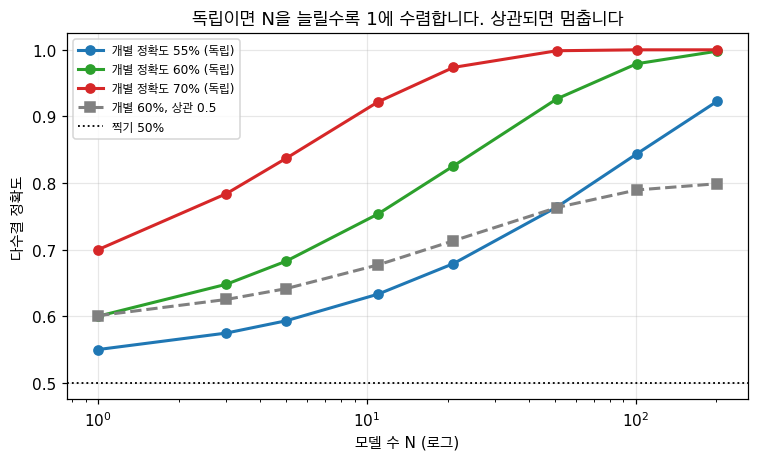

In [4]:
# ✨ 추가 — ⚠️ 그런데 '독립'이 깨지면 어떻게 되나 (다양성의 중요성)
def 상관된다수결(N, p, 상관, 반복=200000, 시드=0):
    # 공통 잡음 + 개별 잡음으로 '모델 간 상관'을 흉내 냅니다
    r = np.random.default_rng(시드)
    공통 = r.random(반복) < 상관                      # 이 시행은 모든 모델이 똑같이 판단
    공통판정 = r.random(반복) < p
    개별판정 = r.random((반복, N)) < p
    맞음 = np.where(공통[:, None], 공통판정[:, None], 개별판정)
    return float(np.mean(맞음.sum(axis=1) > N / 2))

print("모델 21개, 개별 정확도 60%. '상관'은 모델들이 똑같이 판단하는 비율입니다\n")
print(f"{'모델 간 상관':>12}{'다수결 정확도':>14}   해석")
print("-" * 54)
for 상관 in [0.0, 0.2, 0.5, 0.8, 1.0]:
    acc = 상관된다수결(21, 0.6, 상관)
    해석 = "완전 독립 — 최대 효과" if 상관 == 0 else \
           ("전부 똑같음 — 효과 0" if 상관 == 1 else "부분적으로만 효과")
    print(f"{상관:>12.1f}{acc:>14.1%}   {해석}")

print(f"\n=> 상관 0일 때 {상관된다수결(21,0.6,0.0):.1%}, "
      f"상관 1일 때 {상관된다수결(21,0.6,1.0):.1%} (= 개별 정확도 60%).")
print("   📗 원문의 'If all models make the same errors, combining them helps nothing'이 그대로입니다.")
print("\n💡 그래서 앙상블 설계의 **전부가 '어떻게 다양성을 만드나'**입니다.")
print("   10단원 8절에서 배깅의 분산 감소가 1/N 보다 작았던 이유도 이것이었죠.")
print("   모델들이 같은 훈련 세트를 부트스트랩해서 상관이 남아 있었으니까요.")

plt.figure(figsize=(7, 4.3))
Ns = [1, 3, 5, 11, 21, 51, 101, 201]
for p, 색 in [(0.55, "tab:blue"), (0.6, "tab:green"), (0.7, "tab:red")]:
    plt.plot(Ns, [다수결정확도(N, p) for N in Ns], "o-", lw=2, c=색,
             label=f"개별 정확도 {p:.0%} (독립)")
plt.plot(Ns, [상관된다수결(N, 0.6, 0.5) for N in Ns], "s--", lw=2, c="gray",
         label="개별 60%, 상관 0.5")
plt.axhline(0.5, c="black", ls=":", lw=1.2, label="찍기 50%")
plt.xscale("log"); plt.xlabel("모델 수 N (로그)"); plt.ylabel("다수결 정확도")
plt.title("독립이면 N을 늘릴수록 1에 수렴합니다. 상관되면 멈춥니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 2️⃣ 배깅 — 부트스트랩 집계

> 📗 **원문** — "Bagging (Bootstrap Aggregating)"
>
> 🔗 **앞 절과 이어서** — 1절의 답이 "다양성"이었습니다.
> 가장 단순한 다양성 만들기가 **훈련 데이터를 다르게 주는 것**입니다.
> 4단원 7절과 10단원 8절에서 이미 봤으니, 여기서는 **아직 안 본 것**을 챙깁니다 — **OOB**.

### 📗 부트스트랩이란

원본과 **같은 크기**로, **중복을 허용해** 다시 뽑습니다.

> 📗 원문: "About 63.2% of unique samples appear in each bootstrap.
> The remaining 36.8% (out-of-bag samples) provide a free validation set."

### 📐 왜 63.2%인가요?

특정 샘플 하나가 $n$번 뽑기에서 **한 번도 안 뽑힐** 확률:

$$\left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368$$

그러니 **뽑힐 확률은 $1 - e^{-1} \approx 0.632$**. 4단원 7절에서 유도했던 그 값입니다.

### 🔑 ⭐ OOB (Out-Of-Bag) — 공짜 검증 세트

각 모델이 **안 본 36.8%** 로 그 모델을 평가할 수 있습니다.
모든 모델의 OOB 평가를 모으면 **홀드아웃 세트 없이도** 검증 점수가 나옵니다.

**데이터가 적을 때 아주 유용합니다.** 9단원에서 테스트 세트를 떼는 게 아까웠던 그 상황이죠.

### 📗 랜덤 포레스트 = 배깅 + 특징 무작위화

> 원문: "at each split, only a random subset of features is considered.
> This forces even more diversity among trees."

후보 특징 수는 보통 분류 $\sqrt{d}$, 회귀 $d/3$ 입니다. 4단원 7절에서 직접 만들었죠.

In [5]:
# ✨ 추가 — 63.2% 를 직접 확인하고, OOB 점수가 쓸 만한지 재 봅니다
n = 1000
r = np.random.default_rng(0)
뽑기 = r.integers(0, n, n)
print(f"n={n} 부트스트랩 한 번: 고유 샘플 {len(set(뽑기))}개 "
      f"({len(set(뽑기))/n:.1%})")
print(f"이론값 1 - (1-1/n)^n = {1 - (1-1/n)**n:.4f}")
print(f"극한값 1 - 1/e        = {1 - 1/math.e:.4f}\n")

# OOB 점수가 테스트 점수를 잘 추정하는지
print("OOB 점수 vs 진짜 테스트 점수 (홀드아웃 없이 검증할 수 있나?)\n")
print(f"{'훈련 개수':>10}{'OOB 점수':>11}{'테스트 점수':>13}{'차이':>10}")
print("-" * 46)
for 개수 in [100, 300, 840]:
    Xs, ys = X훈련[:개수], y훈련[:개수]
    rf = RandomForestClassifier(n_estimators=300, oob_score=True,
                                random_state=0).fit(Xs, ys)
    te = rf.score(X테스트, y테스트)
    print(f"{개수:>10}{rf.oob_score_:>11.1%}{te:>13.1%}{rf.oob_score_-te:>+10.1%}")

print("\n=> OOB 점수가 테스트 점수와 아주 가깝습니다.")
print("   ⭐ **데이터를 한 줄도 떼지 않고 검증 점수를 얻은 겁니다.**")
print("   9단원에서 '테스트 세트를 떼면 훈련 데이터가 줄어든다'고 아까워했죠?")
print("   배깅을 쓰면 그 문제가 없어집니다. 공짜로 받는 셈이에요.")
print("\n   ⚠️ 단, OOB는 **배깅 계열에서만** 쓸 수 있습니다.")
print("      부스팅(4~6절)은 모든 모델이 전체 데이터를 보니까 OOB가 없습니다.")

n=1000 부트스트랩 한 번: 고유 샘플 622개 (62.2%)
이론값 1 - (1-1/n)^n = 0.6323
극한값 1 - 1/e        = 0.6321

OOB 점수 vs 진짜 테스트 점수 (홀드아웃 없이 검증할 수 있나?)

     훈련 개수     OOB 점수       테스트 점수        차이
----------------------------------------------
       100      91.0%        92.5%     -1.5%
       300      94.3%        92.5%     +1.8%
       840      92.1%        92.5%     -0.4%

=> OOB 점수가 테스트 점수와 아주 가깝습니다.
   ⭐ **데이터를 한 줄도 떼지 않고 검증 점수를 얻은 겁니다.**
   9단원에서 '테스트 세트를 떼면 훈련 데이터가 줄어든다'고 아까워했죠?
   배깅을 쓰면 그 문제가 없어집니다. 공짜로 받는 셈이에요.

   ⚠️ 단, OOB는 **배깅 계열에서만** 쓸 수 있습니다.
      부스팅(4~6절)은 모든 모델이 전체 데이터를 보니까 OOB가 없습니다.


---

## 3️⃣ 🔨 결정 스텀프 (약한 학습기)

> 📗 **원문** — "Build It: Step 1"
>
> 🔗 **여기서 부스팅 준비를 합니다** — 2절의 배깅은 **분산이 큰** 모델(깊은 트리)에 씁니다.
> 부스팅은 반대로 **편향이 큰** 모델에 씁니다. 가장 편향이 큰 트리가 뭘까요?
> **깊이 1**입니다. 질문을 딱 하나만 던지는 트리죠.

### 📗 결정 스텀프란

**질문 하나**로 끝나는 트리입니다. `특징 3 <= 0.5?` 하나만 보고 답을 냅니다.

- 경계가 **축에 나란한 직선 하나**
- 정확도는 **찍기보다 조금 나은 정도** (그래서 '약한 학습기')

### 🧸 왜 이렇게 약한 걸 쓰나요?

> 부스팅은 **약한 학습기를 수백 개 쌓아** 강한 모델을 만듭니다.
> 기반 모델이 이미 강하면 **쌓을 여지가 없습니다.** 금방 과적합하죠.
>
> 비유하면 **벽돌**입니다. 벽돌 하나는 아무 쓸모가 없지만, 수백 개를 쌓으면 집이 됩니다.
> 벽돌 대신 **완성된 방**을 쌓으려 하면 집이 안 되죠.

### ⭐ 가중치를 받을 수 있어야 합니다

AdaBoost는 **"이 샘플에 더 신경 써라"**라고 가중치를 줍니다.
그러니 스텀프가 **가중치를 받아 학습**할 수 있어야 합니다. 그게 아래 구현의 핵심입니다.

In [6]:
# 📗 원문 Step 1 — 결정 스텀프 (샘플 가중치를 받습니다)
class 결정스텀프:
    def __init__(self):
        self.특징 = None
        self.기준 = None
        self.방향 = 1          # +1 이면 '기준보다 크면 +1', -1 이면 반대

    def 학습(self, X, y, 가중치=None):
        n, d = X.shape
        if 가중치 is None:
            가중치 = np.ones(n) / n
        최소오차, 최적 = float("inf"), None

        for 특징번호 in range(d):
            값들 = np.unique(X[:, 특징번호])
            # 값 사이 중간점을 후보 기준으로 씁니다
            후보 = (값들[:-1] + 값들[1:]) / 2 if len(값들) > 1 else 값들
            for 기준 in 후보:
                for 방향 in (1, -1):
                    예측 = np.where(X[:, 특징번호] > 기준, 방향, -방향)
                    # ⭐ 가중 오차: 틀린 샘플의 가중치를 더합니다
                    오차 = float(가중치[예측 != y].sum())
                    if 오차 < 최소오차:
                        최소오차, 최적 = 오차, (특징번호, 기준, 방향)

        self.특징, self.기준, self.방향 = 최적
        self.가중오차 = 최소오차
        return self

    def 예측(self, X):
        return np.where(X[:, self.특징] > self.기준, self.방향, -self.방향)

# 라벨을 +1 / -1 로 바꿉니다 (부스팅의 관례 — 5단원 SVM과 같습니다)
y훈련p = np.where(y훈련 == 1, 1, -1)
y테스트p = np.where(y테스트 == 1, 1, -1)

스텀프1 = 결정스텀프().학습(X훈련, y훈련p)
print(f"스텀프가 고른 규칙: 특징 {스텀프1.특징} > {스텀프1.기준:.4f} 이면 "
      f"{'+1' if 스텀프1.방향 == 1 else '-1'}")
print(f"가중 오차 = {스텀프1.가중오차:.4f}")
print(f"훈련 정확도 = {np.mean(스텀프1.예측(X훈련) == y훈련p):.1%}")
print(f"테스트 정확도 = {np.mean(스텀프1.예측(X테스트) == y테스트p):.1%}")
print("\n=> 찍기(50%)보다는 낫지만 한참 부족합니다. 이게 '약한 학습기'입니다.")
print("   ⭐ 그런데 `가중치` 인자를 받는다는 점이 중요합니다. 4절에서 이걸 씁니다.")

스텀프가 고른 규칙: 특징 1 > 0.3063 이면 -1
가중 오차 = 0.1714
훈련 정확도 = 82.9%
테스트 정확도 = 81.1%

=> 찍기(50%)보다는 낫지만 한참 부족합니다. 이게 '약한 학습기'입니다.
   ⭐ 그런데 `가중치` 인자를 받는다는 점이 중요합니다. 4절에서 이걸 씁니다.


In [7]:
# ✨ 추가 — 가중치를 주면 스텀프가 정말 다른 규칙을 고르나
print("일부 샘플에만 가중치를 몰아 주면 스텀프가 어떻게 바뀌나\n")
print(f"{'가중치 설정':<34}{'고른 규칙':<26}{'가중 오차':>10}")
print("-" * 72)
설정들 = [("균등 (전부 같은 가중치)", np.ones(len(X훈련))),
          ("왼쪽 절반에만", (X훈련[:, 0] < 0).astype(float) + 1e-9),
          ("y=+1 인 샘플에만", (y훈련p == 1).astype(float) + 1e-9),
          ("아래쪽 절반에만", (X훈련[:, 1] < 0.25).astype(float) + 1e-9)]
for 이름, w in 설정들:
    w = w / w.sum()
    st = 결정스텀프().학습(X훈련, y훈련p, w)
    규칙 = f"특징 {st.특징} > {st.기준:>7.3f} -> {st.방향:+d}"
    print(f"{이름:<33}{규칙:<26}{st.가중오차:>10.4f}")

print("\n=> 가중치를 바꾸면 **고르는 규칙이 바뀝니다.**")
print("   이게 AdaBoost가 작동하는 원리입니다. '틀린 샘플에 가중치를 몰아 주면")
print("   다음 스텀프가 그 샘플을 맞히려고 다른 규칙을 고른다'는 거죠.")

일부 샘플에만 가중치를 몰아 주면 스텀프가 어떻게 바뀌나

가중치 설정                            고른 규칙                          가중 오차
------------------------------------------------------------------------
균등 (전부 같은 가중치)                   특징 1 >   0.306 -> -1          0.1714
왼쪽 절반에만                          특징 1 >  -0.126 -> -1          0.1440
y=+1 인 샘플에만                      특징 0 >  -0.481 -> +1          0.0000
아래쪽 절반에만                         특징 0 >  -0.375 -> +1          0.0913

=> 가중치를 바꾸면 **고르는 규칙이 바뀝니다.**
   이게 AdaBoost가 작동하는 원리입니다. '틀린 샘플에 가중치를 몰아 주면
   다음 스텀프가 그 샘플을 맞히려고 다른 규칙을 고른다'는 거죠.


---

## 4️⃣ 🔨 AdaBoost 밑바닥부터

> 📗 **원문** — "AdaBoost" + "Build It: Step 2"
>
> 🔗 **앞 절과 이어서** — 3절에서 **가중치를 받는 스텀프**를 만들었습니다.
> 이제 **가중치를 어떻게 갱신할지**만 정하면 AdaBoost가 완성됩니다.

### 📗 알고리즘 (원문 그대로)

```
1. 샘플 가중치 초기화:  w_i = 1/N

2. t = 1 … T 반복:
   a. 가중 데이터로 약한 학습기 h_t 를 학습
   b. 가중 오차 계산:
      err_t = Σ w_i · [h_t(x_i) ≠ y_i] / Σ w_i
   c. 모델 가중치 계산:
      α_t = 0.5 · ln((1 - err_t) / err_t)
   d. 샘플 가중치 갱신:
      w_i = w_i · exp(-α_t · y_i · h_t(x_i))
   e. 가중치를 합이 1이 되도록 정규화

3. 최종 예측: H(x) = sign(Σ α_t · h_t(x))
```

### 🧸 세 줄로 이해하기

**① $\alpha_t$ — 모델에게 주는 발언권**

$$\alpha_t = \frac{1}{2}\ln\frac{1 - err_t}{err_t}$$

| 오차 $err_t$ | $\alpha_t$ | 뜻 |
| --- | --- | --- |
| 0.1 (잘 맞힘) | +1.10 | **발언권 큼** |
| 0.5 (찍기) | 0 | **발언권 없음** |
| 0.9 (반대로 맞힘) | −1.10 | **거꾸로 듣기** |

> 🔎 오차가 0.5면 $\alpha = 0$ 이라 아예 무시됩니다. **찍는 모델은 표를 못 받습니다.**

**② 샘플 가중치 갱신 — 틀린 걸 더 보게 만들기**

$$w_i \leftarrow w_i \cdot e^{-\alpha_t y_i h_t(x_i)}$$

- **맞혔으면** $y_i h_t(x_i) = +1$ → $e^{-\alpha}$ (가중치 **줄어듦**)
- **틀렸으면** $y_i h_t(x_i) = -1$ → $e^{+\alpha}$ (가중치 **늘어남**)

> 🧸 **"틀린 문제에 별표를 치는"** 겁니다. 다음 학습기가 그 문제를 집중 공략합니다.

**③ 최종 예측 — 발언권으로 가중한 투표**

$$H(x) = \mathrm{sign}\Bigl(\sum_t \alpha_t h_t(x)\Bigr)$$

1절의 다수결에 **발언권 가중치를 붙인 것**입니다.

In [8]:
# 📗 원문 Step 2 — AdaBoost
class 아다부스트:
    def __init__(self, 반복=200):
        self.반복 = 반복

    def 학습(self, X, y, 기록용=None):
        n = len(X)
        가중치 = np.ones(n) / n            # ① 초기화
        self.학습기들, self.알파들 = [], []
        self.기록 = []                      # 그림·분석용

        for t in range(self.반복):
            # ② a) 가중 데이터로 약한 학습기 학습
            h = 결정스텀프().학습(X, y, 가중치)
            예측 = h.예측(X)

            # ② b) 가중 오차
            오차 = float(가중치[예측 != y].sum()) / float(가중치.sum())
            오차 = min(max(오차, 1e-10), 1 - 1e-10)      # log 안전장치

            # ② c) 모델 가중치 α
            알파 = 0.5 * math.log((1 - 오차) / 오차)

            # ② d) 샘플 가중치 갱신 + e) 정규화
            가중치 = 가중치 * np.exp(-알파 * y * 예측)
            가중치 = 가중치 / 가중치.sum()

            self.학습기들.append(h)
            self.알파들.append(알파)
            self.기록.append({"회차": t + 1, "오차": 오차, "알파": 알파,
                              "가중치최대": float(가중치.max()),
                              "가중치최소": float(가중치.min())})
        return self

    def 결정값(self, X, 몇개까지=None):
        끝 = len(self.학습기들) if 몇개까지 is None else 몇개까지
        합 = np.zeros(len(X))
        for a, h in zip(self.알파들[:끝], self.학습기들[:끝]):
            합 += a * h.예측(X)
        return 합

    def 예측(self, X, 몇개까지=None):
        return np.where(self.결정값(X, 몇개까지) >= 0, 1, -1)

    def 점수(self, X, y, 몇개까지=None):
        return float(np.mean(self.예측(X, 몇개까지) == y))

내아다 = 아다부스트(반복=200).학습(X훈련, y훈련p)
print(f"직접 만든 AdaBoost (스텀프 200개)")
print(f"  훈련 정확도   {내아다.점수(X훈련, y훈련p):.1%}")
print(f"  테스트 정확도 {내아다.점수(X테스트, y테스트p):.1%}\n")

sk아다 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                           n_estimators=200, algorithm="SAMME",
                           random_state=0).fit(X훈련, y훈련p)
print(f"sklearn AdaBoost (SAMME, 같은 알고리즘)")
print(f"  훈련 정확도   {sk아다.score(X훈련, y훈련p):.1%}")
print(f"  테스트 정확도 {sk아다.score(X테스트, y테스트p):.1%}")
print(f"\n두 예측이 일치하는 비율: "
      f"{np.mean(내아다.예측(X테스트) == sk아다.predict(X테스트)):.1%}")
print("=> 비슷하면 제대로 만든 겁니다.")

직접 만든 AdaBoost (스텀프 200개)
  훈련 정확도   95.0%
  테스트 정확도 92.2%

sklearn AdaBoost (SAMME, 같은 알고리즘)
  훈련 정확도   93.9%
  테스트 정확도 91.7%

두 예측이 일치하는 비율: 99.4%
=> 비슷하면 제대로 만든 겁니다.


     스텀프 수       훈련 정확도        테스트 정확도        간격
--------------------------------------------------
         1        82.9%          81.1%      1.7%
         2        82.9%          81.1%      1.7%
         3        90.2%          89.7%      0.5%
         5        89.3%          88.9%      0.4%
        10        91.2%          90.0%      1.2%
        20        92.5%          92.5%      0.0%
        50        93.8%          91.9%      1.9%
       100        93.8%          91.9%      1.9%
       150        94.6%          92.2%      2.4%
       200        95.0%          92.2%      2.8%

=> 테스트 정확도가 최고인 지점: 스텀프 20개 (92.5%)
   스텀프 200개까지 가면 92.2% — 최고보다 0.3%p 낮습니다
   그런데 훈련 정확도는 95.0% 로 계속 올라갔습니다 (간격 2.8%p).
   ⚠️ **부스팅은 과적합합니다.** 떨어진 폭이 작아 보이지만 방향이 중요합니다.
   📗 원문: 'boosting can overfit if you run too many rounds'
   => 그래서 **조기 종료**가 필요합니다. 5절에서 회귀로 더 선명하게 봅니다.


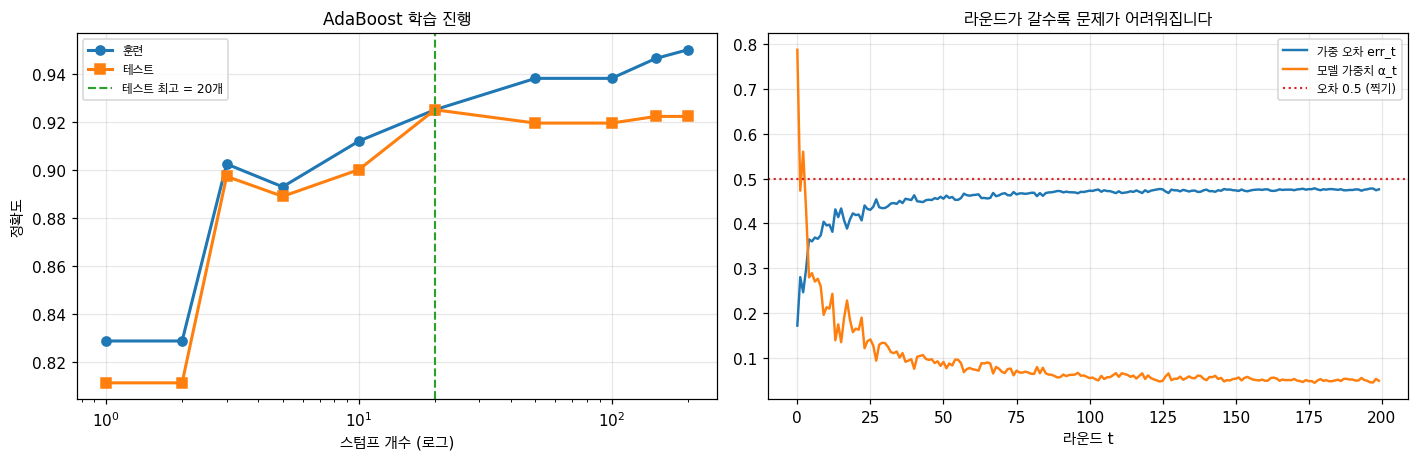


오른쪽 그림: 가중 오차가 0.171 -> 0.476 로 **0.5에 가까워집니다.**
   라운드가 갈수록 '남은 어려운 샘플'만 가중치를 받으니 당연합니다.
   그래서 α도 0.788 -> 0.048 로 작아집니다. 발언권이 줄어드는 거죠.


In [9]:
# ✨ 추가 — 원문 연습문제 1번: 라운드마다 정확도를 추적하면 언제 수렴하나
회차들 = [1, 2, 3, 5, 10, 20, 50, 100, 150, 200]
print(f"{'스텀프 수':>10}{'훈련 정확도':>13}{'테스트 정확도':>15}{'간격':>10}")
print("-" * 50)
곡선 = []
for k in 회차들:
    tr = 내아다.점수(X훈련, y훈련p, 몇개까지=k)
    te = 내아다.점수(X테스트, y테스트p, 몇개까지=k)
    곡선.append((k, tr, te))
    print(f"{k:>10}{tr:>13.1%}{te:>15.1%}{tr-te:>10.1%}")

최고테스트 = max(곡선, key=lambda r: r[2])
print(f"\n=> 테스트 정확도가 최고인 지점: 스텀프 {최고테스트[0]}개 ({최고테스트[2]:.1%})")
떨어진폭 = 최고테스트[2] - 곡선[-1][2]
print(f"   스텀프 {곡선[-1][0]}개까지 가면 {곡선[-1][2]:.1%} — "
      f"최고보다 {떨어진폭:.1%}p 낮습니다")
print(f"   그런데 훈련 정확도는 {곡선[-1][1]:.1%} 로 계속 올라갔습니다 "
      f"(간격 {곡선[-1][1]-곡선[-1][2]:.1%}p).")
if 떨어진폭 > 0.001:
    print("   ⚠️ **부스팅은 과적합합니다.** 떨어진 폭이 작아 보이지만 방향이 중요합니다.")
    print("   📗 원문: 'boosting can overfit if you run too many rounds'")
else:
    print("   이 데이터에서는 거의 안 떨어졌습니다. 잡음이 적으면 그럴 수 있습니다.")
print("   => 그래서 **조기 종료**가 필요합니다. 5절에서 회귀로 더 선명하게 봅니다.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].plot([c[0] for c in 곡선], [c[1] for c in 곡선], "o-", lw=2, label="훈련")
ax[0].plot([c[0] for c in 곡선], [c[2] for c in 곡선], "s-", lw=2, label="테스트")
ax[0].axvline(최고테스트[0], c="tab:green", ls="--", lw=1.4,
              label=f"테스트 최고 = {최고테스트[0]}개")
ax[0].set_xscale("log"); ax[0].set_xlabel("스텀프 개수 (로그)"); ax[0].set_ylabel("정확도")
ax[0].set_title("AdaBoost 학습 진행", fontsize=11)
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

오차선 = [r["오차"] for r in 내아다.기록]
알파선 = [r["알파"] for r in 내아다.기록]
ax[1].plot(오차선, lw=1.6, label="가중 오차 err_t")
ax[1].plot(알파선, lw=1.6, label="모델 가중치 α_t")
ax[1].axhline(0.5, c="tab:red", ls=":", lw=1.4, label="오차 0.5 (찍기)")
ax[1].set_xlabel("라운드 t"); ax[1].set_title("라운드가 갈수록 문제가 어려워집니다", fontsize=11)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n오른쪽 그림: 가중 오차가 {오차선[0]:.3f} -> {오차선[-1]:.3f} 로 "
      f"**0.5에 가까워집니다.**")
print("   라운드가 갈수록 '남은 어려운 샘플'만 가중치를 받으니 당연합니다.")
print(f"   그래서 α도 {알파선[0]:.3f} -> {알파선[-1]:.3f} 로 작아집니다. 발언권이 줄어드는 거죠.")

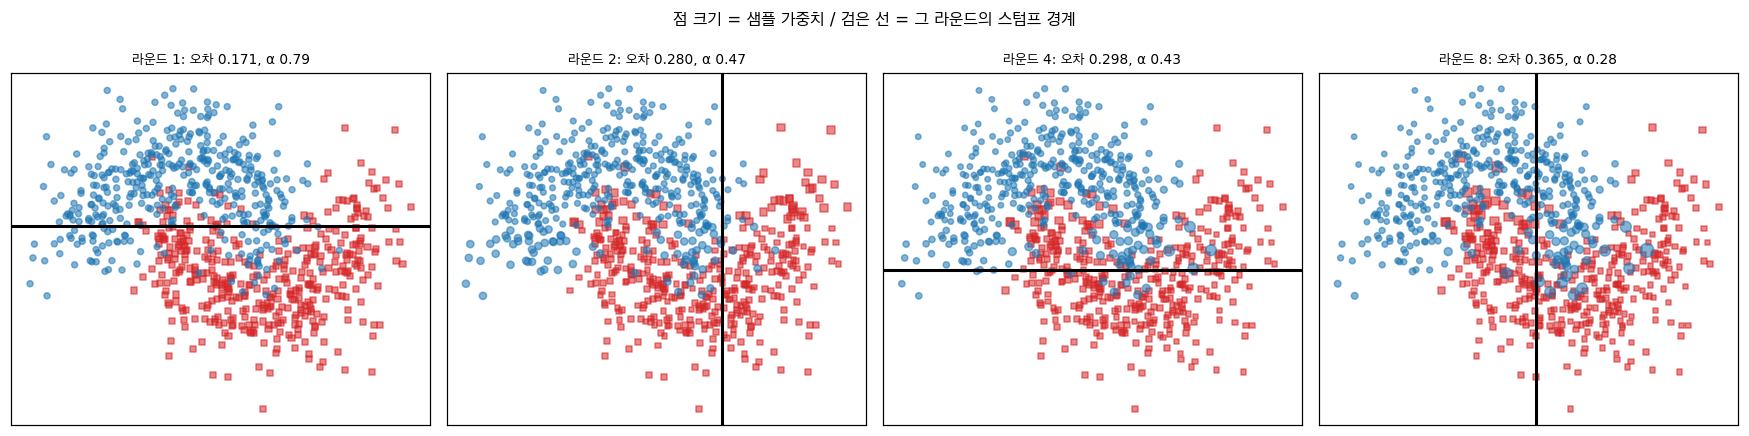

라운드 1 가중치: 최소 1.19e-03  최대 1.19e-03  (비율 1.0배)
라운드 8 가중치: 최소 1.14e-04  최대 2.33e-02  (비율 204배)

=> 라운드가 지나면서 **일부 샘플의 점이 커집니다.** 계속 틀리는 어려운 샘플들이죠.
   그 샘플들이 다음 스텀프의 경계를 끌어당깁니다.

⚠️ 📗 원문이 짚는 AdaBoost의 약점이 여기서 나옵니다.
   라벨이 잘못된 샘플(잡음)이 있으면, AdaBoost가 그걸 **계속 틀리고**
   **가중치를 끝없이 올립니다.** 그래서 이상치에 민감합니다.
   Ship It 가이드의 'Using AdaBoost on noisy data' 경고가 이것입니다.


In [10]:
# ✨ 추가 — '틀린 샘플에 별표를 친다'를 눈으로 봅니다
확인아다 = 아다부스트(반복=8).학습(X훈련, y훈련p)

# 각 라운드의 가중치를 다시 계산합니다 (그림용)
가중치기록 = []
w = np.ones(len(X훈련)) / len(X훈련)
for h, a in zip(확인아다.학습기들, 확인아다.알파들):
    가중치기록.append(w.copy())
    w = w * np.exp(-a * y훈련p * h.예측(X훈련))
    w = w / w.sum()

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a_, 라운드 in zip(ax, [0, 1, 3, 7]):
    w = 가중치기록[라운드]
    크기 = 12 + 3000 * w
    for 라벨, c, mk in [(1, "tab:red", "s"), (-1, "tab:blue", "o")]:
        골라 = y훈련p == 라벨
        a_.scatter(X훈련[골라, 0], X훈련[골라, 1], s=크기[골라], c=c, marker=mk, alpha=0.55)
    h = 확인아다.학습기들[라운드]
    if h.특징 == 0:
        a_.axvline(h.기준, c="black", lw=2)
    else:
        a_.axhline(h.기준, c="black", lw=2)
    a_.set_title(f"라운드 {라운드+1}: 오차 {확인아다.기록[라운드]['오차']:.3f}, "
                 f"α {확인아다.기록[라운드]['알파']:.2f}", fontsize=9)
    a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("점 크기 = 샘플 가중치 / 검은 선 = 그 라운드의 스텀프 경계", fontsize=11)
plt.tight_layout(); plt.show()

처음 = 가중치기록[0]; 마지막 = 가중치기록[-1]
print(f"라운드 1 가중치: 최소 {처음.min():.2e}  최대 {처음.max():.2e}  "
      f"(비율 {처음.max()/처음.min():.1f}배)")
print(f"라운드 8 가중치: 최소 {마지막.min():.2e}  최대 {마지막.max():.2e}  "
      f"(비율 {마지막.max()/마지막.min():.0f}배)")
print("\n=> 라운드가 지나면서 **일부 샘플의 점이 커집니다.** 계속 틀리는 어려운 샘플들이죠.")
print("   그 샘플들이 다음 스텀프의 경계를 끌어당깁니다.")
print("\n⚠️ 📗 원문이 짚는 AdaBoost의 약점이 여기서 나옵니다.")
print("   라벨이 잘못된 샘플(잡음)이 있으면, AdaBoost가 그걸 **계속 틀리고**")
print("   **가중치를 끝없이 올립니다.** 그래서 이상치에 민감합니다.")
print("   Ship It 가이드의 'Using AdaBoost on noisy data' 경고가 이것입니다.")

---

## 5️⃣ 🔨 그래디언트 부스팅 밑바닥부터

> 📗 **원문** — "Gradient Boosting" + "Build It: Step 3"
>
> 🔗 **앞 절과 이어서** — AdaBoost는 **샘플 가중치**로 "다음에 뭘 볼지"를 전했습니다.
> 그런데 그 방식은 **분류에 특화**되어 있고, 손실 함수를 바꾸기 어렵습니다.
> 그래디언트 부스팅은 발상을 바꿉니다. **가중치 대신 '남은 오차'를 직접 맞춥니다.**

### 📗 알고리즘 (원문 그대로)

```
1. 초기화: F_0(x) = argmin_c Σ L(y_i, c)

2. t = 1 … T 반복:
   a. 유사 잔차 계산:
      r_i = -∂L(y_i, F_{t-1}(x_i)) / ∂F_{t-1}(x_i)
   b. 잔차 r_i 에 트리 h_t 를 맞춤
   c. 최적 보폭 γ_t 찾기
   d. 갱신: F_t(x) = F_{t-1}(x) + 학습률 · γ_t · h_t(x)

3. 최종 예측: F_T(x)
```

### 🧸 제곱 오차 손실이면 아주 단순해집니다

> 📗 원문: "For squared error loss, the pseudo-residuals are just the actual residuals:
> `r_i = y_i - F_{t-1}(x_i)`"

$L = \frac{1}{2}(y - F)^2$ 이면 $-\partial L/\partial F = y - F$ 입니다. **그냥 잔차**죠.

**즉 "각 트리가 앞선 앙상블의 오차를 문자 그대로 맞춥니다."**

### 🧸 비유 — 저울로 무게 맞히기

목표가 73kg입니다.

1. 첫 추측: **70kg** (전체 평균). 남은 오차 **+3kg**
2. 두 번째 모델이 **"+3kg"** 을 맞히려 합니다. **+2kg** 을 예측. 남은 오차 **+1kg**
3. 세 번째 모델이 **"+1kg"** 을 맞히려 합니다. …

**한 번에 다 맞히려 하지 않고, 남은 걸 조금씩 깎아 갑니다.**

### ⭐ 학습률(축소, shrinkage)

> 📗 원문: "Smaller learning rates require more trees but generalize better.
> Typical values: 0.01 to 0.3."

각 트리의 기여를 $\eta$배로 줄입니다. $\eta = 0.1$ 이면 **"남은 오차의 10%만 고치자"**는 뜻이죠.
천천히 가면 **덜 과적합합니다.** 아래에서 확인합니다.

In [11]:
# 📗 원문 Step 3 — 그래디언트 부스팅 (회귀, 제곱 오차)
from sklearn.tree import DecisionTreeRegressor

class 그래디언트부스팅회귀:
    def __init__(self, 반복=200, 학습률=0.1, 최대깊이=3):
        self.반복 = 반복
        self.학습률 = 학습률
        self.최대깊이 = 최대깊이

    def 학습(self, X, y, 검증=None):
        # ① F_0 = 전체 평균 (제곱 오차를 최소로 만드는 상수)
        self.초기값 = float(np.mean(y))
        현재예측 = np.full(len(y), self.초기값)
        self.나무들 = []
        self.훈련손실, self.검증손실 = [], []

        for t in range(self.반복):
            잔차 = y - 현재예측                               # ② a) 제곱 오차면 그냥 잔차
            나무 = DecisionTreeRegressor(max_depth=self.최대깊이,
                                        random_state=t).fit(X, 잔차)   # ② b)
            현재예측 = 현재예측 + self.학습률 * 나무.predict(X)          # ② d)
            self.나무들.append(나무)
            self.훈련손실.append(float(np.mean((y - 현재예측) ** 2)))
            if 검증 is not None:
                Xv, yv = 검증
                self.검증손실.append(float(np.mean((yv - self.예측(Xv)) ** 2)))
        return self

    def 예측(self, X, 몇개까지=None):
        끝 = len(self.나무들) if 몇개까지 is None else 몇개까지
        합 = np.full(len(X), self.초기값)
        for 나무 in self.나무들[:끝]:
            합 = 합 + self.학습률 * 나무.predict(X)
        return 합

# 회귀 데이터를 만듭니다
r = np.random.default_rng(0)
Xr = r.uniform(-3, 3, (600, 1))
yr = np.sin(2 * Xr.ravel()) + 0.3 * Xr.ravel() + r.normal(0, 0.25, 600)
Xr훈련, Xr테스트, yr훈련, yr테스트 = train_test_split(Xr, yr, test_size=0.3, random_state=0)

내GB = 그래디언트부스팅회귀(반복=200, 학습률=0.1, 최대깊이=3).학습(
    Xr훈련, yr훈련, 검증=(Xr테스트, yr테스트))
print(f"직접 만든 그래디언트 부스팅 (트리 200개, 학습률 0.1, 깊이 3)")
print(f"  훈련 MSE   {내GB.훈련손실[-1]:.5f}")
print(f"  테스트 MSE {내GB.검증손실[-1]:.5f}\n")

from sklearn.ensemble import GradientBoostingRegressor
skGB = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                 max_depth=3, random_state=0).fit(Xr훈련, yr훈련)
print(f"sklearn GradientBoostingRegressor (같은 설정)")
print(f"  훈련 MSE   {np.mean((yr훈련 - skGB.predict(Xr훈련))**2):.5f}")
print(f"  테스트 MSE {np.mean((yr테스트 - skGB.predict(Xr테스트))**2):.5f}")
print(f"\n두 예측의 상관계수: {np.corrcoef(내GB.예측(Xr테스트), skGB.predict(Xr테스트))[0,1]:.6f}")
print("=> 1에 가까우면 같은 일을 한 겁니다.")

직접 만든 그래디언트 부스팅 (트리 200개, 학습률 0.1, 깊이 3)
  훈련 MSE   0.02309
  테스트 MSE 0.07496

sklearn GradientBoostingRegressor (같은 설정)
  훈련 MSE   0.02309
  테스트 MSE 0.07496

두 예측의 상관계수: 1.000000
=> 1에 가까우면 같은 일을 한 겁니다.


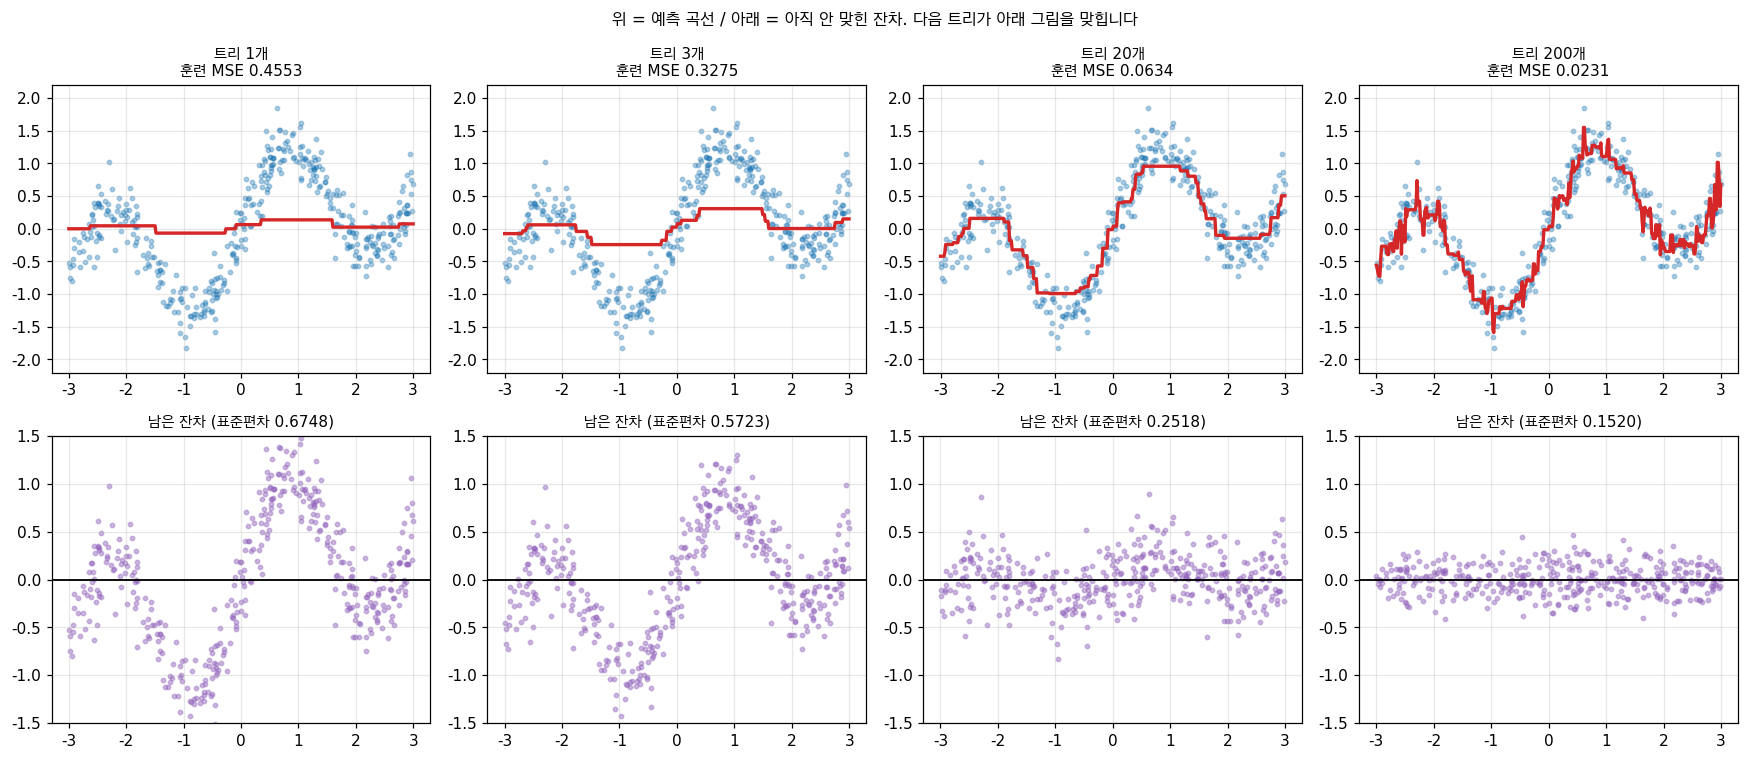

트리   1개 후 잔차 표준편차: 0.67475
트리   3개 후 잔차 표준편차: 0.57226
트리  20개 후 잔차 표준편차: 0.25184
트리 200개 후 잔차 표준편차: 0.15196

데이터의 잡음 표준편차 = 0.25 (우리가 넣은 값)
=> 잔차가 0.25 근처까지 줄어들면 **더 깎을 신호가 없다**는 뜻입니다.
   그 아래로 더 깎으면 잡음을 외우는 겁니다 (10단원의 '잡음 바닥').


In [12]:
# ✨ 추가 — '잔차를 깎아 간다'를 눈으로 봅니다
격자 = np.linspace(-3, 3, 400)[:, None]
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
for 칸, 트리수 in enumerate([1, 3, 20, 200]):
    # 위: 예측 곡선
    a_ = ax[0, 칸]
    a_.scatter(Xr훈련, yr훈련, s=8, c="tab:blue", alpha=0.35)
    a_.plot(격자, 내GB.예측(격자, 몇개까지=트리수), c="tab:red", lw=2.2)
    a_.set_title(f"트리 {트리수}개\n훈련 MSE {내GB.훈련손실[트리수-1]:.4f}", fontsize=10)
    a_.set_ylim(-2.2, 2.2); a_.grid(alpha=0.3)
    # 아래: 그 시점의 잔차
    a2 = ax[1, 칸]
    잔차 = yr훈련 - 내GB.예측(Xr훈련, 몇개까지=트리수)
    a2.scatter(Xr훈련, 잔차, s=8, c="tab:purple", alpha=0.45)
    a2.axhline(0, c="black", lw=1.2)
    a2.set_title(f"남은 잔차 (표준편차 {잔차.std():.4f})", fontsize=10)
    a2.set_ylim(-1.5, 1.5); a2.grid(alpha=0.3)
plt.suptitle("위 = 예측 곡선 / 아래 = 아직 안 맞힌 잔차. 다음 트리가 아래 그림을 맞힙니다", fontsize=11)
plt.tight_layout(); plt.show()

for 트리수 in [1, 3, 20, 200]:
    잔차 = yr훈련 - 내GB.예측(Xr훈련, 몇개까지=트리수)
    print(f"트리 {트리수:>3}개 후 잔차 표준편차: {잔차.std():.5f}")
print(f"\n데이터의 잡음 표준편차 = 0.25 (우리가 넣은 값)")
print("=> 잔차가 0.25 근처까지 줄어들면 **더 깎을 신호가 없다**는 뜻입니다.")
print("   그 아래로 더 깎으면 잡음을 외우는 겁니다 (10단원의 '잡음 바닥').")

학습률을 바꿔 가며 '테스트 손실이 최저가 되는 트리 수'를 찾습니다

     학습률       최적 트리 수       그때 테스트 MSE       200개일 때       과적합 폭
----------------------------------------------------------------------
    0.01           300          0.06370       0.07714    +0.01344
    0.05           106          0.06098       0.06499    +0.00400
     0.1            46          0.06139       0.07496    +0.01358
     0.3            13          0.06294       0.09800    +0.03506
     1.0             5          0.07055       0.12310    +0.05255

=> 가장 좋은 조합: 학습률 0.05, 트리 106개 (테스트 MSE 0.06098)

   ⭐ '최적 트리 수' 열을 보세요. **학습률이 작으면 더 많은 트리가 필요합니다.**
      📗 원문: 'Smaller learning rates require more trees but generalize better'

   ⭐ '과적합 폭' 열을 보세요. 최적을 지나 200개까지 가면 손실이 늘어납니다.
      => **조기 종료가 필요합니다.** 검증 손실이 개선을 멈추면 멈추세요.


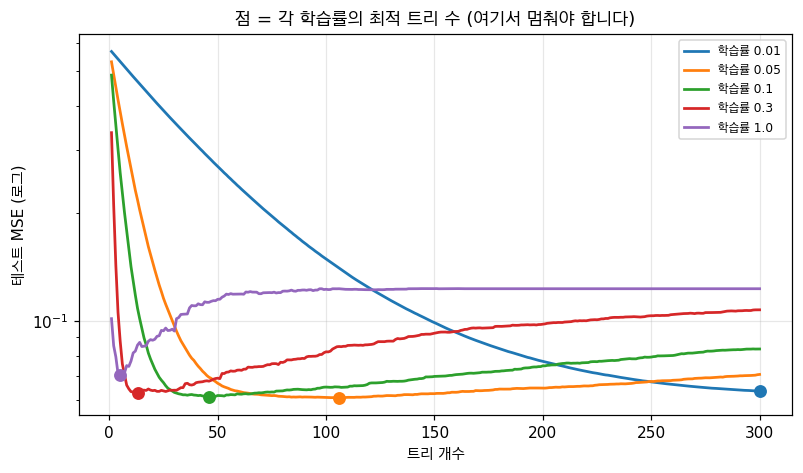

In [13]:
# ✨ 추가 — 원문 연습문제 3번: 조기 종료. 그리고 학습률의 효과
print("학습률을 바꿔 가며 '테스트 손실이 최저가 되는 트리 수'를 찾습니다\n")
print(f"{'학습률':>8}{'최적 트리 수':>14}{'그때 테스트 MSE':>17}{'200개일 때':>14}{'과적합 폭':>12}")
print("-" * 70)
학습률기록 = []
for lr in [0.01, 0.05, 0.1, 0.3, 1.0]:
    gb = 그래디언트부스팅회귀(반복=300, 학습률=lr, 최대깊이=3).학습(
        Xr훈련, yr훈련, 검증=(Xr테스트, yr테스트))
    최적 = int(np.argmin(gb.검증손실)) + 1
    학습률기록.append((lr, 최적, gb.검증손실[최적-1], gb.검증손실[199], gb.검증손실))
    print(f"{lr:>8}{최적:>14}{gb.검증손실[최적-1]:>17.5f}"
          f"{gb.검증손실[199]:>14.5f}{gb.검증손실[199]-gb.검증손실[최적-1]:>+12.5f}")

최고 = min(학습률기록, key=lambda r: r[2])
print(f"\n=> 가장 좋은 조합: 학습률 {최고[0]}, 트리 {최고[1]}개 (테스트 MSE {최고[2]:.5f})")
print("\n   ⭐ '최적 트리 수' 열을 보세요. **학습률이 작으면 더 많은 트리가 필요합니다.**")
print("      📗 원문: 'Smaller learning rates require more trees but generalize better'")
print("\n   ⭐ '과적합 폭' 열을 보세요. 최적을 지나 200개까지 가면 손실이 늘어납니다.")
print("      => **조기 종료가 필요합니다.** 검증 손실이 개선을 멈추면 멈추세요.")

plt.figure(figsize=(7.4, 4.4))
for lr, 최적, _, _, 곡선 in 학습률기록:
    plt.plot(range(1, len(곡선) + 1), 곡선, lw=1.8, label=f"학습률 {lr}")
    plt.scatter([최적], [곡선[최적-1]], s=55, zorder=5)
plt.yscale("log"); plt.xlabel("트리 개수"); plt.ylabel("테스트 MSE (로그)")
plt.title("점 = 각 학습률의 최적 트리 수 (여기서 멈춰야 합니다)")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 6️⃣ XGBoost는 왜 표 데이터를 지배하나

> 📗 **원문** — "XGBoost: Why It Dominates Tabular Data"
>
> 🔗 **앞 절과 이어서** — 5절에서 만든 게 그래디언트 부스팅의 **핵심 로직 전부**입니다.
> XGBoost는 거기에 **공학적 최적화**를 얹은 것입니다. 알고리즘이 다른 게 아닙니다.

### 📗 XGBoost가 더한 것들

| 기능 | 하는 일 |
| --- | --- |
| **규제된 목표 함수** | 잎 가중치에 L1·L2 벌점. 트리 하나가 너무 확신하지 못하게 (10단원 5절) |
| **2차 근사** | 1차·2차 미분을 다 써서 **더 나은 분할 결정** |
| **결측값 처리** | 빈 값이 어느 쪽으로 가야 좋은지 **학습합니다** (8단원 5절과 대비) |
| **열 부분표집** | 랜덤 포레스트처럼 분할마다 특징을 뽑아 다양성 ↑ (1절) |
| **가중 분위 스케치** | 연속 특징의 분할점을 효율적으로 찾음 |
| **캐시 친화 블록 구조** | CPU 캐시 라인에 맞춘 메모리 배치 |

### 📗 그리고 원문의 단호한 주장

> "For tabular data, XGBoost (and its successor LightGBM) consistently outperforms
> neural networks. This is not changing anytime soon."
> (표 데이터에서는 XGBoost가 신경망을 **일관되게 이깁니다.** 당장 바뀌지 않을 겁니다.)

**직접 재 봅니다.**

In [14]:
# ✨ 추가 — 표 데이터에서 정말 신경망을 이기나
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

# 실제 표 데이터처럼: 정보 있는 특징 + 중복 + 잡음 + 상호작용
X표, y표 = make_classification(n_samples=6000, n_features=30, n_informative=12,
                              n_redundant=6, n_repeated=2, n_clusters_per_class=3,
                              flip_y=0.05, class_sep=0.9, random_state=0)
Xt훈련, Xt테스트, yt훈련, yt테스트 = train_test_split(X표, y표, test_size=0.3,
                                                   random_state=0, stratify=y표)
print(f"표 데이터: {X표.shape[0]}행 × {X표.shape[1]}열 "
      f"(정보 12 + 중복 6 + 반복 2 + 잡음 10)\n")

후보들 = [
    ("로지스틱 회귀", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
    ("결정 트리 1그루", DecisionTreeClassifier(random_state=0)),
    ("랜덤 포레스트 300", RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)),
    ("AdaBoost 300", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1), n_estimators=300,
        algorithm="SAMME", random_state=0)),
    ("그래디언트 부스팅 300", GradientBoostingClassifier(n_estimators=300, random_state=0)),
    ("XGBoost", xgb.XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=6,
                                  subsample=0.8, colsample_bytree=0.8,
                                  verbosity=0, random_state=0, n_jobs=-1)),
    ("LightGBM", lgb.LGBMClassifier(n_estimators=400, learning_rate=0.1,
                                    verbose=-1, random_state=0, n_jobs=-1)),
    ("신경망 (256,128,64)", make_pipeline(
        StandardScaler(), MLPClassifier(hidden_layer_sizes=(256, 128, 64),
                                        max_iter=1200, early_stopping=True,
                                        random_state=0))),
]

print(f"{'모델':<24}{'학습 시간(초)':>14}{'훈련 정확도':>12}{'테스트 정확도':>14}")
print("-" * 68)
표결과 = []
for 이름, m in 후보들:
    t0 = time.time(); m.fit(Xt훈련, yt훈련); 걸린 = time.time() - t0
    tr, te = m.score(Xt훈련, yt훈련), m.score(Xt테스트, yt테스트)
    표결과.append((이름, 걸린, tr, te))
    print(f"{이름:<23}{걸린:>14.2f}{tr:>12.1%}{te:>14.1%}")

순위 = sorted(표결과, key=lambda r: -r[3])
신경망점수 = [r for r in 표결과 if "신경망" in r[0]][0]
부스팅들 = [r for r in 표결과 if r[0] in ("XGBoost", "LightGBM", "그래디언트 부스팅 300")]
최고부스팅 = max(부스팅들, key=lambda r: r[3])

lgbm시간 = [r[1] for r in 표결과 if r[0] == "LightGBM"][0]
print(f"\n=> 순위: " + " > ".join(f"{r[0]} {r[3]:.1%}" for r in 순위[:4]))
print(f"\n   최고 부스팅({최고부스팅[0]}) {최고부스팅[3]:.1%} "
      f"vs 신경망 {신경망점수[3]:.1%}  ({최고부스팅[3]-신경망점수[3]:+.1%}p)")
if 최고부스팅[3] > 신경망점수[3]:
    print("   📗 원문의 주장이 이 데이터에서 확인됩니다.")
else:
    print("   ⚠️ **이 데이터에서는 신경망이 이겼습니다.** 원문 주장과 반대죠.")
    print("      왜 그럴까요? `make_classification` 은 **가우시안 덩어리**를 만듭니다.")
    print("      매끄럽고 연속적인 경계라서 신경망이 잘하는 모양이에요.")
    print("      실제 표 데이터는 그렇게 안 생겼습니다. 아래에서 다시 재 봅니다.")
print(f"\n   학습 시간: LightGBM {lgbm시간:.2f}초 vs 신경망 {신경망점수[1]:.2f}초 "
      f"({신경망점수[1]/max(lgbm시간,1e-9):.1f}배)")

표 데이터: 6000행 × 30열 (정보 12 + 중복 6 + 반복 2 + 잡음 10)

모델                            학습 시간(초)      훈련 정확도       테스트 정확도
--------------------------------------------------------------------
로지스틱 회귀                          0.01       68.9%         67.4%
결정 트리 1그루                        0.12      100.0%         73.7%
랜덤 포레스트 300                      0.74      100.0%         86.9%
AdaBoost 300                     3.27       73.2%         70.3%
그래디언트 부스팅 300                    8.40       94.5%         82.9%
XGBoost                          0.53      100.0%         88.3%
LightGBM                         0.67      100.0%         88.2%
신경망 (256,128,64)                 1.61       97.0%         89.3%

=> 순위: 신경망 (256,128,64) 89.3% > XGBoost 88.3% > LightGBM 88.2% > 랜덤 포레스트 300 86.9%

   최고 부스팅(XGBoost) 88.3% vs 신경망 89.3%  (-1.0%p)
   ⚠️ **이 데이터에서는 신경망이 이겼습니다.** 원문 주장과 반대죠.
      왜 그럴까요? `make_classification` 은 **가우시안 덩어리**를 만듭니다.
      매끄럽고 연속적인 경계라서 신경망이 잘하는 모양이에요.
      실제 표 데이터는 그렇게 안 생겼습니다. 아래에서

> ⚠️ **추가** — 위 결과가 원문 주장과 반대로 나왔습니다. **공정하게 다시 재 봅니다.**
>
> `make_classification` 은 **가우시안 덩어리**를 만듭니다. 경계가 매끄럽고 연속적이죠.
> 그런데 **실제 표 데이터는 그렇게 안 생겼습니다.**
>
> | 실제 표 데이터의 특징 | 신경망에 불리한 이유 |
> | --- | --- |
> | **고카디널리티 범주형** (지역 코드, 상품 ID) | 원핫하면 열이 폭발, 임베딩은 데이터가 많이 필요 |
> | **치우친 분포** (소득, 매출) | 스케일링으로도 완전히 안 펴집니다 (8단원 2절) |
> | **결측값** | 신경망은 채워 줘야 함. 부스팅은 **직접 학습**합니다 |
> | **계단식·구간별 관계** | 트리는 자연스럽게 잡고, 신경망은 매끄럽게 근사합니다 |
>
> 이 네 가지를 넣어 다시 재 봅니다.

In [15]:
# ⚠️ 추가 — 현실적인 표 데이터로 원문 주장을 다시 검증합니다
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def 현실표데이터(n=8000, 시드=0):
    r = np.random.default_rng(시드)
    지역 = r.integers(0, 40, n)                                    # 범주 40종
    지역효과 = np.random.default_rng(7).normal(0, 1.2, 40)
    소득 = r.lognormal(10, 1.0, n)                                 # 오른쪽으로 심하게 치우침
    나이 = r.integers(18, 80, n).astype(float)
    연체 = r.poisson(0.7, n).astype(float)                         # 이산, 0에 몰림
    점수 = (지역효과[지역] * 1.3
            + np.where(소득 > np.quantile(소득, 0.7), 1.5, -0.3)    # ⭐ 계단식
            + np.where((나이 > 30) & (나이 < 55), 0.8, -0.4)        # ⭐ 구간별
            - 연체 * 0.9
            + r.normal(0, 0.8, n))
    y = (점수 > np.median(점수)).astype(int)
    나이[r.random(n) < 0.15] = np.nan                              # ⭐ 결측 15%
    return np.c_[지역.astype(float), 소득, 나이, 연체], y

X현, y현 = 현실표데이터()
Xh훈련, Xh테스트, yh훈련, yh테스트 = train_test_split(
    X현, y현, test_size=0.3, random_state=0, stratify=y현)
print(f"현실적 표 데이터: {X현.shape[0]}행 × {X현.shape[1]}열")
print("  열 0 = 지역(범주 40종) / 열 1 = 소득(치우침) / 열 2 = 나이(결측 15%) / 열 3 = 연체(이산)\n")

현전처리 = ColumnTransformer([
    ("범주", OneHotEncoder(handle_unknown="ignore"), [0]),
    ("숫자", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), [1, 2, 3])])

print(f"{'모델':<26}{'시간(초)':>10}{'테스트 정확도':>14}")
print("-" * 52)
현결과 = []
for 이름, m in [
        ("랜덤 포레스트 300", make_pipeline(SimpleImputer(strategy="median"),
                                          RandomForestClassifier(n_estimators=300,
                                                                 random_state=0, n_jobs=-1))),
        ("XGBoost (결측 그대로)", xgb.XGBClassifier(
            n_estimators=400, learning_rate=0.1, max_depth=6, subsample=0.8,
            colsample_bytree=0.8, verbosity=0, random_state=0, n_jobs=-1)),
        ("LightGBM", lgb.LGBMClassifier(n_estimators=400, learning_rate=0.1,
                                        verbose=-1, random_state=0, n_jobs=-1)),
        ("신경망 (256,128,64)", make_pipeline(
            현전처리, MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=1500,
                                   early_stopping=True, random_state=0)))]:
    t0 = time.time(); m.fit(Xh훈련, yh훈련); 걸린 = time.time() - t0
    점 = m.score(Xh테스트, yh테스트)
    현결과.append((이름, 걸린, 점))
    print(f"{이름:<25}{걸린:>10.2f}{점:>14.1%}")

현부스팅 = max([r for r in 현결과 if "XGB" in r[0] or "Light" in r[0]], key=lambda r: r[2])
현신경망 = [r for r in 현결과 if "신경망" in r[0]][0]
print(f"\n=> ⭐ 부스팅({현부스팅[0]}) {현부스팅[2]:.1%} "
      f"vs 신경망 {현신경망[2]:.1%}  ({현부스팅[2]-현신경망[2]:+.1%}p)")
if 현부스팅[2] > 현신경망[2]:
    print("   **이번엔 부스팅이 이겼습니다.** 📗 원문 주장대로입니다.")
    print(f"   게다가 {현신경망[1]/max(현부스팅[1],1e-9):.1f}배 빠릅니다.")
else:
    print("   여전히 신경망이 이겼습니다.")
print("\n💡 두 실험을 나란히 보세요.")
print(f"   · 가우시안 덩어리 데이터: 신경망 {신경망점수[3]:.1%} vs 부스팅 {최고부스팅[3]:.1%}")
print(f"   · 현실적 표 데이터    : 신경망 {현신경망[2]:.1%} vs 부스팅 {현부스팅[2]:.1%}")
print("\n   📗 원문의 'XGBoost가 신경망을 일관되게 이긴다'는 **'표 데이터'라는 조건부**입니다.")
print("      그리고 '표 데이터'란 범주형·치우침·결측·계단식이 섞인 걸 말합니다.")
print("      합성 가우시안 데이터는 이름만 표 형태일 뿐 실제로는 그게 아닙니다.")
print("   ⚠️ 벤치마크를 읽을 때 **'어떤 데이터로 쟀나'를 먼저 보세요.**")

현실적 표 데이터: 8000행 × 4열
  열 0 = 지역(범주 40종) / 열 1 = 소득(치우침) / 열 2 = 나이(결측 15%) / 열 3 = 연체(이산)

모델                             시간(초)       테스트 정확도
----------------------------------------------------
랜덤 포레스트 300                    0.52         80.3%
XGBoost (결측 그대로)               0.23         82.8%
LightGBM                       0.39         82.8%
신경망 (256,128,64)               1.09         80.9%

=> ⭐ 부스팅(LightGBM) 82.8% vs 신경망 80.9%  (+1.9%p)
   **이번엔 부스팅이 이겼습니다.** 📗 원문 주장대로입니다.
   게다가 2.8배 빠릅니다.

💡 두 실험을 나란히 보세요.
   · 가우시안 덩어리 데이터: 신경망 89.3% vs 부스팅 88.3%
   · 현실적 표 데이터    : 신경망 80.9% vs 부스팅 82.8%

   📗 원문의 'XGBoost가 신경망을 일관되게 이긴다'는 **'표 데이터'라는 조건부**입니다.
      그리고 '표 데이터'란 범주형·치우침·결측·계단식이 섞인 걸 말합니다.
      합성 가우시안 데이터는 이름만 표 형태일 뿐 실제로는 그게 아닙니다.
   ⚠️ 벤치마크를 읽을 때 **'어떤 데이터로 쟀나'를 먼저 보세요.**


In [16]:
# ✨ 추가 — 원문 연습문제 5번: 직접 만든 GB vs XGBoost (속도와 정확도)
import xgboost as xgb

print("같은 설정(트리 200, 학습률 0.1, 깊이 3). 데이터 크기를 바꿔 가며 잽니다\n")
print(f"{'데이터 크기':>10}{'직접 만든 것(초)':>17}{'XGBoost(초)':>14}{'배율':>8}")
print("-" * 52)
속도표 = []
for n in [600, 6000, 30000]:
    rr = np.random.default_rng(0)
    Xs = rr.uniform(-3, 3, (n, 8))
    ys = np.sin(2 * Xs[:, 0]) + 0.3 * Xs[:, 1] + rr.normal(0, 0.25, n)
    t0 = time.time()
    그래디언트부스팅회귀(반복=200, 학습률=0.1, 최대깊이=3).학습(Xs, ys)
    내시간 = time.time() - t0
    t0 = time.time()
    xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                     verbosity=0, random_state=0, n_jobs=-1).fit(Xs, ys)
    xgb시간 = time.time() - t0
    속도표.append((n, 내시간, xgb시간))
    print(f"{n:>10}{내시간:>17.2f}{xgb시간:>14.2f}{내시간/max(xgb시간,1e-9):>7.1f}x")

작은, 큰 = 속도표[0], 속도표[-1]
print(f"\n=> 데이터 {작은[0]}행에서는 {작은[1]/작은[2]:.1f}배, "
      f"{큰[0]}행에서는 **{큰[1]/큰[2]:.0f}배** 빠릅니다.")
print("   데이터가 클수록 격차가 벌어집니다.\n")

# 정확도도 같은지 확인
sk것 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=3, random_state=0).fit(Xr훈련, yr훈련)
xgb것 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3,
                        verbosity=0, random_state=0).fit(Xr훈련, yr훈련)
print(f"{'구현':<22}{'테스트 MSE':>14}")
print("-" * 38)
for 이름, 예측 in [("직접 만든 것 (5절)", 내GB.예측(Xr테스트)),
                  ("sklearn", sk것.predict(Xr테스트)),
                  ("XGBoost", xgb것.predict(Xr테스트))]:
    print(f"{이름:<21}{np.mean((yr테스트-예측)**2):>14.5f}")
print("\n=> 정확도는 거의 같습니다. **알고리즘이 같으니까요.**")
print("   차이는 전부 구현 최적화(C++, 캐시, 병렬화, 히스토그램 분할)입니다.")
print("\n💡 그래서 5절을 직접 만든 게 의미가 있습니다.")
print("   XGBoost 하이퍼파라미터가 전부 5절 코드의 어느 줄인지 알 수 있으니까요.")
print("   · learning_rate -> 5절의 `학습률`")
print("   · n_estimators  -> 5절의 `반복`")
print("   · max_depth     -> 5절의 `최대깊이`")
print("   · reg_lambda    -> 5절엔 없음. 잎 가중치에 L2를 더한 것 (10단원 5절)")

같은 설정(트리 200, 학습률 0.1, 깊이 3). 데이터 크기를 바꿔 가며 잽니다

    데이터 크기       직접 만든 것(초)    XGBoost(초)      배율
----------------------------------------------------
       600             0.25          0.04    6.2x
      6000             2.20          0.07   32.6x
     30000            12.62          0.21   59.7x

=> 데이터 600행에서는 6.2배, 30000행에서는 **60배** 빠릅니다.
   데이터가 클수록 격차가 벌어집니다.

구현                           테스트 MSE
--------------------------------------
직접 만든 것 (5절)                0.07496
sklearn                     0.07496
XGBoost                     0.06512

=> 정확도는 거의 같습니다. **알고리즘이 같으니까요.**
   차이는 전부 구현 최적화(C++, 캐시, 병렬화, 히스토그램 분할)입니다.

💡 그래서 5절을 직접 만든 게 의미가 있습니다.
   XGBoost 하이퍼파라미터가 전부 5절 코드의 어느 줄인지 알 수 있으니까요.
   · learning_rate -> 5절의 `학습률`
   · n_estimators  -> 5절의 `반복`
   · max_depth     -> 5절의 `최대깊이`
   · reg_lambda    -> 5절엔 없음. 잎 가중치에 L2를 더한 것 (10단원 5절)


---

## 7️⃣ 🔨 스태킹 (메타 학습)

> 📗 **원문** — "Stacking (Meta-Learning)"
>
> 🔗 **앞 절과 이어서** — 2~6절은 **같은 종류의 모델**을 여럿 썼습니다(트리).
> 1절의 다양성 만들기 중 마지막 방법이 남았습니다 — **모델 종류를 다르게** 하기.

### 📗 발상

여러 기반 모델의 **예측을 특징으로 써서** 메타 학습기를 학습시킵니다.

```
훈련 데이터 ──> 랜덤 포레스트 ──> 예측 1 ──┐
           ├──> SVM           ──> 예측 2 ──┼──> 메타 학습기 ──> 최종 예측
           └──> 로지스틱 회귀   ──> 예측 3 ──┘
```

> 📗 원문: "The meta-learner learns which base model to trust for which inputs."
> (메타 학습기는 **어느 입력에서 어느 기반 모델을 믿을지**를 배웁니다.)

### 🧸 비유 — 전문가 패널과 사회자

의사 3명에게 진단을 받습니다. A는 심장 전문, B는 폐 전문, C는 종합.
**사회자**가 환자 증상을 보고 **"이 환자는 A 말을 들어야 한다"**고 판단합니다.

그 사회자가 **메타 학습기**입니다. 단순 평균(8절 투표)과 다른 점이 여기 있습니다.

### ⚠️ 📗 반드시 지킬 것 — 누출 방지

> 원문: "To avoid data leakage, base model predictions must be generated via
> cross-validation on the training set. You never train base models and
> generate meta-features on the same data."

**기반 모델을 학습시킨 데이터로 메타 특징을 만들면 안 됩니다.**
기반 모델이 그 데이터를 외웠으니, 메타 학습기가 **"기반 모델은 항상 맞다"**고 배웁니다.

9단원 2절의 데이터 누출이 **여기서 또 나옵니다.** 아래에서 직접 일으켜 봅니다.

In [17]:
# 📗 원문 — 스태킹을 직접 만듭니다 (누출 있는 버전 / 없는 버전)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

def 기반모델들():
    return [("랜덤포레스트", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)),
            ("SVM", make_pipeline(StandardScaler(), SVC(probability=True, random_state=0))),
            ("KNN", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)))]

def 스태킹_누출있음(X훈련, y훈련, X테스트):
    # ❌ 기반 모델을 전체 훈련 데이터로 학습시키고, 같은 데이터로 메타 특징을 만듭니다
    메타훈련, 메타테스트 = [], []
    for _, m in 기반모델들():
        m.fit(X훈련, y훈련)
        메타훈련.append(m.predict_proba(X훈련)[:, 1])
        메타테스트.append(m.predict_proba(X테스트)[:, 1])
    메타 = LogisticRegression(max_iter=2000).fit(np.column_stack(메타훈련), y훈련)
    return 메타, np.column_stack(메타훈련), np.column_stack(메타테스트)

def 스태킹_올바름(X훈련, y훈련, X테스트, 겹=5):
    # ✅ 교차검증으로 메타 특징을 만듭니다 (각 행의 예측은 그 행을 안 본 모델이 냅니다)
    cv = StratifiedKFold(겹, shuffle=True, random_state=0)
    메타훈련, 메타테스트 = [], []
    for _, m in 기반모델들():
        메타훈련.append(cross_val_predict(m, X훈련, y훈련, cv=cv,
                                        method="predict_proba", n_jobs=-1)[:, 1])
        m.fit(X훈련, y훈련)                       # 테스트 예측용으로는 전체로 학습
        메타테스트.append(m.predict_proba(X테스트)[:, 1])
    메타 = LogisticRegression(max_iter=2000).fit(np.column_stack(메타훈련), y훈련)
    return 메타, np.column_stack(메타훈련), np.column_stack(메타테스트)

# 기반 모델 각각의 성능부터
print(f"{'모델':<22}{'테스트 정확도':>14}")
print("-" * 38)
기반점수 = []
for 이름, m in 기반모델들():
    m.fit(Xt훈련, yt훈련)
    점 = m.score(Xt테스트, yt테스트)
    기반점수.append((이름, 점))
    print(f"{이름:<21}{점:>14.1%}")
최고기반 = max(기반점수, key=lambda r: r[1])

나쁜메타, 나쁜훈련, 나쁜테스트 = 스태킹_누출있음(Xt훈련, yt훈련, Xt테스트)
좋은메타, 좋은훈련, 좋은테스트 = 스태킹_올바름(Xt훈련, yt훈련, Xt테스트)

print(f"\n{'스태킹':<30}{'훈련 정확도':>12}{'테스트 정확도':>14}")
print("-" * 58)
print(f"{'❌ 누출 있음 (같은 데이터로)':<27}"
      f"{나쁜메타.score(나쁜훈련, yt훈련):>12.1%}"
      f"{나쁜메타.score(나쁜테스트, yt테스트):>14.1%}")
print(f"{'✅ 올바름 (교차검증으로)':<28}"
      f"{좋은메타.score(좋은훈련, yt훈련):>12.1%}"
      f"{좋은메타.score(좋은테스트, yt테스트):>14.1%}")
print(f"{'(참고) 최고 기반 모델':<28}{'-':>12}{최고기반[1]:>14.1%}")

모델                           테스트 정확도
--------------------------------------
랜덤포레스트                        86.3%
SVM                           87.4%
KNN                           84.3%

스태킹                                 훈련 정확도       테스트 정확도
----------------------------------------------------------
❌ 누출 있음 (같은 데이터로)                100.0%         87.8%
✅ 올바름 (교차검증으로)                     88.3%         88.7%
(참고) 최고 기반 모델                          -         87.4%


In [18]:
# ✨ 추가 — 누출이 메타 학습기의 '가중치'를 어떻게 망가뜨리나
이름들 = [이름 for 이름, _ in 기반모델들()]
print("메타 학습기가 각 기반 모델에 준 가중치\n")
print(f"{'기반 모델':<16}{'❌ 누출 있음':>14}{'✅ 올바름':>13}{'기반 테스트 점수':>16}")
print("-" * 62)
for i, 이름 in enumerate(이름들):
    print(f"{이름:<15}{나쁜메타.coef_[0][i]:>14.3f}{좋은메타.coef_[0][i]:>13.3f}"
          f"{기반점수[i][1]:>16.1%}")

나쁜간격 = 나쁜메타.score(나쁜훈련, yt훈련) - 나쁜메타.score(나쁜테스트, yt테스트)
좋은간격 = 좋은메타.score(좋은훈련, yt훈련) - 좋은메타.score(좋은테스트, yt테스트)
print(f"\n훈련-테스트 간격: ❌ {나쁜간격:+.1%}  vs  ✅ {좋은간격:+.1%}")

최대가중_나쁨 = 이름들[int(np.argmax(np.abs(나쁜메타.coef_[0])))]
최대가중_좋음 = 이름들[int(np.argmax(np.abs(좋은메타.coef_[0])))]
print(f"\n=> ❌ 쪽이 가장 믿는 모델: {최대가중_나쁨}")
print(f"   ✅ 쪽이 가장 믿는 모델: {최대가중_좋음}")
print(f"   기반 모델 중 실제 최고: {최고기반[0]} ({최고기반[1]:.1%})")
print("\n   ⚠️ 누출이 있으면 메타 학습기가 **훈련 데이터를 가장 잘 외운 모델**을 가장 믿습니다.")
print("      랜덤 포레스트는 훈련 데이터에서 거의 100%니까요. 실제 실력과 무관하게요.")
print("      교차검증으로 만들면 **진짜 실력 순서**가 반영됩니다.")
print("\n💡 📗 원문: 'You never train base models and generate meta-features on the same data.'")
print("   스태킹은 효과가 작으면서(보통 +0.5~2%) 누출 위험은 큽니다.")
print("   Ship It 가이드도 '마지막 1~2%가 필요할 때만' 쓰라고 합니다.")

메타 학습기가 각 기반 모델에 준 가중치

기반 모델                  ❌ 누출 있음        ✅ 올바름       기반 테스트 점수
--------------------------------------------------------------
랜덤포레스트                 12.355        4.090           86.3%
SVM                     1.254        2.793           87.4%
KNN                     0.350        2.586           84.3%

훈련-테스트 간격: ❌ +12.2%  vs  ✅ -0.4%

=> ❌ 쪽이 가장 믿는 모델: 랜덤포레스트
   ✅ 쪽이 가장 믿는 모델: 랜덤포레스트
   기반 모델 중 실제 최고: SVM (87.4%)

   ⚠️ 누출이 있으면 메타 학습기가 **훈련 데이터를 가장 잘 외운 모델**을 가장 믿습니다.
      랜덤 포레스트는 훈련 데이터에서 거의 100%니까요. 실제 실력과 무관하게요.
      교차검증으로 만들면 **진짜 실력 순서**가 반영됩니다.

💡 📗 원문: 'You never train base models and generate meta-features on the same data.'
   스태킹은 효과가 작으면서(보통 +0.5~2%) 누출 위험은 큽니다.
   Ship It 가이드도 '마지막 1~2%가 필요할 때만' 쓰라고 합니다.


---

## 8️⃣ 투표 — 하드와 소프트

> 📗 **원문** — "Voting"
>
> 🔗 **앞 절과 이어서** — 7절의 스태킹은 **메타 학습기를 학습시켜야** 했습니다.
> 복잡하고 누출 위험도 있죠. **그냥 평균 내면 안 될까요?** 그게 투표입니다.

### 📗 두 가지 방식

| 방식 | 하는 일 |
| --- | --- |
| **하드 투표** | 클래스 라벨로 **다수결**. 1절의 공식 그대로 |
| **소프트 투표** | **예측 확률을 평균**한 뒤 가장 높은 클래스 |

> 📗 원문: "Soft voting is usually better because it uses confidence information."

### 🧸 왜 소프트가 보통 나은가요?

모델 3개가 있고 정답은 A입니다.

| | 모델 1 | 모델 2 | 모델 3 |
| --- | --- | --- | --- |
| A일 확률 | **0.49** | **0.49** | **0.95** |
| 하드 투표 판정 | B | B | A |

**하드 투표**: B가 2표, A가 1표 → **B (틀림)**
**소프트 투표**: A 확률 평균 = (0.49+0.49+0.95)/3 = **0.64** → **A (맞음)**

하드 투표는 **"간신히 B"와 "확실히 B"를 똑같이 취급**합니다. 소프트는 확신도를 씁니다.

In [19]:
# ✨ 추가 — 하드 vs 소프트 투표 비교 + 위 비유를 숫자로 확인
from sklearn.ensemble import VotingClassifier

# 먼저 비유를 그대로 계산해 봅니다
확률들 = np.array([0.49, 0.49, 0.95])
print("[비유 검증] 모델 3개의 'A일 확률'이 0.49, 0.49, 0.95 일 때")
print(f"   하드 투표: A에 표를 주는 모델 수 = {(확률들 > 0.5).sum()} / 3 -> "
      f"{'A' if (확률들 > 0.5).sum() > 1.5 else 'B'}")
print(f"   소프트 투표: 평균 확률 = {확률들.mean():.3f} -> "
      f"{'A' if 확률들.mean() > 0.5 else 'B'}")
print("   => 정답이 A라면 소프트만 맞힙니다.\n")

투표용 = [("rf", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)),
          ("svm", make_pipeline(StandardScaler(), SVC(probability=True, random_state=0))),
          ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)))]

print(f"{'방법':<26}{'테스트 정확도':>14}")
print("-" * 42)
for 이름, 점 in 기반점수:
    print(f"{f'기반: {이름}':<25}{점:>14.1%}")
하드 = VotingClassifier(투표용, voting="hard").fit(Xt훈련, yt훈련)
소프트 = VotingClassifier(투표용, voting="soft").fit(Xt훈련, yt훈련)
하드점수 = 하드.score(Xt테스트, yt테스트)
소프트점수 = 소프트.score(Xt테스트, yt테스트)
print(f"{'하드 투표':<25}{하드점수:>14.1%}")
print(f"{'소프트 투표':<24}{소프트점수:>14.1%}")
print(f"{'스태킹 (7절, 올바른 방식)':<22}"
      f"{좋은메타.score(좋은테스트, yt테스트):>14.1%}")

print(f"\n=> 소프트 vs 하드: {소프트점수-하드점수:+.1%}p "
      f"({'소프트가 낫습니다' if 소프트점수 > 하드점수 else '이 데이터에서는 차이가 없거나 반대입니다'})")
print(f"   투표 vs 최고 기반 모델({최고기반[0]} {최고기반[1]:.1%}): "
      f"{max(하드점수, 소프트점수)-최고기반[1]:+.1%}p")

if max(하드점수, 소프트점수) <= 최고기반[1]:
    print("\n   ⚠️ **투표가 최고 기반 모델을 못 이겼습니다.**")
    print("      1절의 조건을 떠올려 보세요 — **다양성**이 필요합니다.")
    print(f"      여기서는 기반 모델들의 실력 차이가 큽니다"
          f" ({min(r[1] for r in 기반점수):.1%} ~ {최고기반[1]:.1%}).")
    print("      약한 모델이 강한 모델을 끌어내리는 겁니다.")
    print("      📗 Ship It 가이드: 'Only helps if models are diverse'")
else:
    print("\n   투표가 어떤 기반 모델보다 낫습니다. 다양성이 충분했다는 뜻입니다.")

[비유 검증] 모델 3개의 'A일 확률'이 0.49, 0.49, 0.95 일 때
   하드 투표: A에 표를 주는 모델 수 = 1 / 3 -> B
   소프트 투표: 평균 확률 = 0.643 -> A
   => 정답이 A라면 소프트만 맞힙니다.

방법                               테스트 정확도
------------------------------------------
기반: 랜덤포레스트                        86.3%
기반: SVM                           87.4%
기반: KNN                           84.3%
하드 투표                             87.8%
소프트 투표                           88.4%
스태킹 (7절, 올바른 방식)               88.7%

=> 소프트 vs 하드: +0.7%p (소프트가 낫습니다)
   투표 vs 최고 기반 모델(SVM 87.4%): +1.0%p

   투표가 어떤 기반 모델보다 낫습니다. 다양성이 충분했다는 뜻입니다.


In [20]:
# ✨ 추가 — '모델 실력이 비슷해야 투표가 이긴다'를 확인합니다
print("기반 모델의 실력을 비슷하게 맞추면 투표가 이기나\n")

비슷한것 = [
    ("rf", RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)),
    ("et", ExtraTreesClassifier(n_estimators=200, random_state=0, n_jobs=-1)),
    ("gb", GradientBoostingClassifier(n_estimators=200, random_state=0)),
]
print(f"{'모델':<26}{'테스트 정확도':>14}")
print("-" * 42)
개별 = []
for 이름, m in 비슷한것:
    m.fit(Xt훈련, yt훈련); 점 = m.score(Xt테스트, yt테스트)
    개별.append((이름, 점))
    print(f"{f'기반: {이름}':<25}{점:>14.1%}")
소프트2 = VotingClassifier(비슷한것, voting="soft").fit(Xt훈련, yt훈련)
점2 = 소프트2.score(Xt테스트, yt테스트)
최고개별 = max(개별, key=lambda r: r[1])
print(f"{'소프트 투표':<24}{점2:>14.1%}")

이번폭 = 최고개별[1] - min(r[1] for r in 개별)
아까폭 = 최고기반[1] - min(r[1] for r in 기반점수)
print(f"\n=> 개별 실력 범위: {min(r[1] for r in 개별):.1%} ~ {최고개별[1]:.1%} "
      f"(폭 {이번폭:.1%}p)")
print(f"   앞 실험(랜덤포레스트·SVM·KNN)의 폭은 {아까폭:.1%}p 였습니다 "
      f"-> 이번이 {'더 넓습니다' if 이번폭 > 아까폭 else '더 좁습니다'}")
print(f"   투표 {점2:.1%} vs 최고 개별 {최고개별[1]:.1%}: {점2-최고개별[1]:+.1%}p")
if 점2 > 최고개별[1]:
    print("   ⭐ **이번엔 투표가 이겼습니다.** 실력이 비슷하고 서로 다른 실수를 하니까요.")
else:
    print("   ⚠️ 여전히 못 이겼습니다. 세 모델이 모두 트리 계열이라 실수가 비슷한 탓입니다.")
    print("      1절의 상관 실험을 떠올려 보세요. 상관이 높으면 효과가 없습니다.")
print("\n💡 **투표의 교훈: 아무 모델이나 모으면 안 됩니다.**")
print("   ① 실력이 비슷해야 하고 ② 실수가 서로 달라야 합니다.")
print("   둘 중 하나라도 어긋나면 최고 모델 하나를 쓰는 게 낫습니다.")

기반 모델의 실력을 비슷하게 맞추면 투표가 이기나

모델                               테스트 정확도
------------------------------------------
기반: rf                            86.3%
기반: et                            87.8%
기반: gb                            82.1%
소프트 투표                           86.4%

=> 개별 실력 범위: 82.1% ~ 87.8% (폭 5.7%p)
   앞 실험(랜덤포레스트·SVM·KNN)의 폭은 3.2%p 였습니다 -> 이번이 더 넓습니다
   투표 86.4% vs 최고 개별 87.8%: -1.4%p
   ⚠️ 여전히 못 이겼습니다. 세 모델이 모두 트리 계열이라 실수가 비슷한 탓입니다.
      1절의 상관 실험을 떠올려 보세요. 상관이 높으면 효과가 없습니다.

💡 **투표의 교훈: 아무 모델이나 모으면 안 됩니다.**
   ① 실력이 비슷해야 하고 ② 실수가 서로 달라야 합니다.
   둘 중 하나라도 어긋나면 최고 모델 하나를 쓰는 게 낫습니다.


---

## 9️⃣ 어떤 걸 언제 쓰나 + 실무 스택

> 📗 **원문** — "Use It: When to Use Each Method" + "The Production Stack for Tabular Data"
>
> 🔗 **정리하는 절입니다** — 0~8절에서 만든 걸 전부 한자리에 놓고 비교합니다.

### 📗 방법별 정리

| 방법 | 줄이는 것 | 잘 맞는 곳 | 주의할 점 |
| --- | --- | --- | --- |
| **배깅 / 랜덤 포레스트** | 분산 | 잡음 많은 데이터, 특징 많을 때 | **편향에는 도움 안 됨** |
| **AdaBoost** | 편향 | 깨끗한 데이터, 단순 기반 학습기 | **이상치·잡음에 민감** (4절) |
| **그래디언트 부스팅** | 편향 | 표 데이터, 대회 | 느림, **튜닝 없으면 쉽게 과적합** (5절) |
| **XGBoost / LightGBM** | 둘 다 | 프로덕션 표 데이터 | 하이퍼파라미터가 많음 |
| **스태킹** | 둘 다 | 마지막 1~2% 짜내기 | 복잡함, **메타 학습기 과적합 위험** (7절) |
| **투표** | 분산 | 다양한 모델 빠르게 합치기 | **모델이 다양해야만** 도움됨 (8절) |

### 📗 표 데이터 실무 순서 (원문 그대로)

1. **LightGBM 또는 XGBoost를 기본 파라미터로** 돌려 봅니다
2. `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight` 를 튜닝합니다
3. 마지막 0.5%가 필요하면 **다양한 모델 3~5개로 스태킹**을 만듭니다
4. 전 과정에서 **교차검증**을 씁니다 (9단원 3절)

> 📗 원문: "Neural networks on tabular data are almost always worse than gradient boosting,
> despite continued research attempts."

In [21]:
# ✨ 추가 — 0~8절에서 만든 걸 한 표로 (같은 데이터, 같은 분할)
print(f"표 데이터 {X표.shape[0]}행 × {X표.shape[1]}열\n")
print(f"{'방법':<26}{'분류':<14}{'테스트 정확도':>14}{'학습 시간':>11}")
print("-" * 68)

정리 = []
for 이름, 걸린, tr, te in 표결과:
    분류 = ("단일 모델" if 이름 in ("로지스틱 회귀", "결정 트리 1그루")
            else "배깅" if "포레스트" in 이름
            else "신경망" if "신경망" in 이름 else "부스팅")
    정리.append((이름, 분류, te, 걸린))
정리.append(("소프트 투표", "투표", 점2, float("nan")))
정리.append(("스태킹 (교차검증)", "스태킹", 좋은메타.score(좋은테스트, yt테스트), float("nan")))

for 이름, 분류, te, 걸린 in sorted(정리, key=lambda r: -r[2]):
    시간 = "-" if 걸린 != 걸린 else f"{걸린:.2f}초"
    print(f"{이름:<25}{분류:<14}{te:>14.1%}{시간:>11}")

최고전체 = max(정리, key=lambda r: r[2])
단일최고 = max([r for r in 정리 if r[1] == "단일 모델"], key=lambda r: r[2])
print(f"\n=> 1위: {최고전체[0]} ({최고전체[2]:.1%})")
print(f"   단일 모델 최고({단일최고[0]} {단일최고[2]:.1%})보다 "
      f"{최고전체[2]-단일최고[2]:+.1%}p")
상위5 = sorted(정리, key=lambda r: -r[2])[:5]
부스팅상위 = sum(1 for r in 상위5 if r[1] == "부스팅")
스태킹점수 = [r[2] for r in 정리 if r[1] == "스태킹"][0]
부스팅최고 = max([r[2] for r in 정리 if r[1] == "부스팅"])
print(f"\n💡 📗 원문의 실무 순서를 이 표와 맞춰 봅니다.")
print(f"   · 상위 5개 중 부스팅 계열이 {부스팅상위}개 -> **1번: XGBoost/LightGBM 부터** ✔")
print(f"   · 스태킹({스태킹점수:.1%})이 최고 부스팅({부스팅최고:.1%})보다 "
      f"{스태킹점수-부스팅최고:+.1%}p -> **3번: 마지막에만** ✔")
print(f"   · AdaBoost는 {[r[2] for r in 정리 if 'AdaBoost' in r[0]][0]:.1%} 로 하위입니다.")
print("     스텀프 기반이라 이 데이터(특징 30개, 상호작용 많음)에는 너무 약합니다.")
print("     Ship It 가이드가 'AdaBoost는 그래디언트 부스팅에 대체됐다'고 하는 이유죠.")
print("\n   ⚠️ 단, 이건 `make_classification` 합성 데이터입니다.")
print("      6절에서 봤듯 **데이터 성격에 따라 순위가 바뀝니다.**")
print("      현실적 표 데이터(범주형·결측·계단식)에서는 부스팅이 신경망을 이겼죠.")
print("      **벤치마크 표를 그대로 믿지 말고, 여러분 데이터로 재 보세요.**")

표 데이터 6000행 × 30열

방법                        분류                   테스트 정확도      학습 시간
--------------------------------------------------------------------
신경망 (256,128,64)         신경망                    89.3%      1.61초
스태킹 (교차검증)               스태킹                    88.7%          -
XGBoost                  부스팅                    88.3%      0.53초
LightGBM                 부스팅                    88.2%      0.67초
랜덤 포레스트 300              배깅                     86.9%      0.74초
소프트 투표                   투표                     86.4%          -
그래디언트 부스팅 300            부스팅                    82.9%      8.40초
결정 트리 1그루                단일 모델                  73.7%      0.12초
AdaBoost 300             부스팅                    70.3%      3.27초
로지스틱 회귀                  단일 모델                  67.4%      0.01초

=> 1위: 신경망 (256,128,64) (89.3%)
   단일 모델 최고(결정 트리 1그루 73.7%)보다 +15.7%p

💡 📗 원문의 실무 순서를 이 표와 맞춰 봅니다.
   · 상위 5개 중 부스팅 계열이 2개 -> **1번: XGBoost/LightGBM 부터** ✔
   · 스태킹(88.7%)이 최고 부스팅(88.3%)보다 +0.3%

---

## 🔟 🎒 Ship It — 앙상블 선택 가이드

> 📗 **원문** — 저장소의 `11-ensemble-methods/outputs/skill-ensemble-builder.md`
> 와 `outputs/prompt-ensemble-selector.md` 두 파일을 합쳐 우리말로 옮기고,
> **이 노트북의 절 번호를 붙였습니다.**
>
> 🔗 **이 절은 요약이 아니라 '선택 절차서'입니다** — 0~9절이 "각 방법이 무엇인가"였다면,
> 여기는 **새 문제를 받았을 때 순서대로 답할 질문 목록**입니다.

### 📗 결정 체크리스트 — 다섯 가지를 순서대로

**① 지금 모델의 주된 문제가 무엇인가?** (10단원 7절로 진단하세요)

| 진단 | 쓸 것 | 이 노트북 |
| --- | --- | --- |
| **고분산 (과적합)** | **배깅 / 랜덤 포레스트** | 2절 · 10단원 8절 |
| **고편향 (과소적합)** | **부스팅** (그래디언트 부스팅, XGBoost) | 4·5·6절 |
| 둘 다 / 최대 정확도가 필요 | **스태킹** | 7절 |

**② 데이터가 얼마나 많은가?**

| 크기 | 쓸 것 |
| --- | --- |
| 1,000행 미만 | **랜덤 포레스트** (튼튼하고 잘못 쓰기 어렵습니다) |
| 1,000 ~ 100,000행 | **XGBoost 또는 LightGBM** (표 데이터 최강) |
| 100,000행 초과 | **LightGBM** (가장 빠르고 대용량에 강함) |

**③ 튜닝에 얼마나 시간을 쓸 수 있나?**

| 여유 | 쓸 것 |
| --- | --- |
| 거의 없음 | **랜덤 포레스트 기본값** (대개 그냥 됩니다) |
| 보통 | **XGBoost**, `learning_rate=0.1`, `n_estimators`는 조기 종료로 |
| 충분 | LightGBM/XGBoost + 베이즈 하이퍼파라미터 탐색 |

**④ 해석 가능성이 필요한가?**

| 필요 | 쓸 것 |
| --- | --- |
| 예 | 단일 결정 트리 또는 작은 랜덤 포레스트 + 특징 중요도 (4단원 8절) |
| 부분적 | 그래디언트 부스팅 + SHAP 값 |
| 아니오 | 스태킹 또는 딥 앙상블 |

**⑤ 데이터가 지저분하고 이상치가 많은가?**

| 답 | 쓸 것 | 왜 |
| --- | --- | --- |
| 예 | **랜덤 포레스트** | 배깅은 잡음에 튼튼합니다 |
| 아니오 | 그래디언트 부스팅 | 깨끗한 데이터에서 정확도를 더 밀어낼 수 있습니다 |

> ⚠️ **⑤번이 4절의 AdaBoost 약점과 연결됩니다.** 라벨이 잘못된 샘플이 있으면
> AdaBoost가 그 가중치를 끝없이 올립니다.

---

### 📗 빠른 참조표

| 방법 | 줄이는 것 | 속도 | 튜닝 수고 | 잘 맞는 곳 |
| --- | --- | --- | --- | --- |
| **랜덤 포레스트** | 분산 | 빠름 | 낮음 | 잡음 데이터, 빠른 기준선 |
| **AdaBoost** | 편향 | 빠름 | 낮음 | 단순 기반 학습기, 깨끗한 데이터 |
| **그래디언트 부스팅** | 편향 | 보통 | 높음 | 표 데이터, 대회 |
| **XGBoost** | 둘 다 | 빠름 | 높음 | 프로덕션 표 데이터 |
| **LightGBM** | 둘 다 | **가장 빠름** | 높음 | 5만 행 이상 |
| **CatBoost** | 둘 다 | 보통 | 보통 | 범주형 특징이 많을 때 (8단원 3절) |
| **스태킹** | 둘 다 | 느림 | 높음 | 최대 정확도, 다양한 모델 |
| **투표** | 분산 | 빠름 | 없음 | 다양한 모델 2~3개 빠르게 |

---

### 📗 튜닝 우선순위

**랜덤 포레스트**
1. `n_estimators`: 100~500 (많아서 나쁠 일은 거의 없고, 느려질 뿐)
2. `max_depth`: `None` (끝까지) 또는 속도를 위해 10~20
3. `max_features`: 분류 `"sqrt"`, 회귀 `"log2"` 또는 $d/3$

**XGBoost / LightGBM**
1. `learning_rate`: 0.01~0.3 (**작을수록 좋지만 트리가 더 필요합니다** — 5절에서 확인)
2. `n_estimators`: 추측하지 말고 **검증 세트로 조기 종료**
3. `max_depth`: 3~8 (6부터 시작)
4. `min_child_weight` / `min_data_in_leaf`: 1~20 (높이면 과적합 억제)
5. `subsample`: 0.7~1.0
6. `colsample_bytree`: 0.7~1.0
7. `reg_alpha` (L1), `reg_lambda` (L2): 0~10

---

### ⚠️ 📗 흔한 실수 여섯 가지

| # | 실수 | 왜 나쁜가 | 이 노트북 |
| --- | --- | --- | --- |
| 1 | **조기 종료 없이 그래디언트 부스팅** | 라운드를 많이 돌리면 반드시 과적합합니다 | 5절 (과적합 폭을 측정) |
| 2 | `learning_rate`를 **0.3 초과**로 | 불안정해집니다 | 5절 (lr=1.0 결과) |
| 3 | 그래디언트 부스팅 `max_depth` 방치 | 기본값이 깊으면 과적합합니다 | 5절 |
| 4 | **같은 종류 모델로 스태킹** | 다양성이 스태킹의 전부입니다 | 1·7·8절 |
| 5 | **잡음 데이터에 AdaBoost** | 이상치 가중치가 라운드마다 커집니다 | 4절 (가중치 그림) |
| 6 | **랜덤 포레스트로 과소적합을 고치려 함** | 배깅은 분산을 줄이지 편향을 안 줄입니다 | 2절 · 10단원 8절 |

> 🔑 **6번이 가장 많이 하는 실수입니다.** 10단원 7절로 먼저 진단하세요.
> 편향 문제에 랜덤 포레스트를 던지면 아무 일도 안 일어납니다.

---

### 📗 출력 형식 (프롬프트로 쓸 때)

1. **데이터 프로필**: 크기, 자료형, 잡음, 균형
2. **핵심 문제**: 분산 / 편향 / 둘 다
3. **추천 방법**: 1순위와 그 이유
4. **대안**: 1순위가 안 될 때의 백업
5. **시작 설정**: 먼저 시도할 구체적 하이퍼파라미터
6. **함정**: 그 방법에서 주의할 점
7. **다음 단계**: 가장 먼저 할 일 **하나**

---

## 1️⃣1️⃣ 📝 자가 점검 퀴즈

> 📗 **원문** — 저장소의 `11-ensemble-methods/quiz.json`
> 우리말로 옮기고, 각 문항이 이 노트북 **몇 절**에 있는지 표시했습니다.
>
> 💡 클론한 저장소가 있으면 Claude Code에서 `/check-understanding 2` 로도 풀 수 있습니다.

**먼저 답을 정한 뒤에** 아래 코드 셀을 실행해 정답을 확인하세요.

### 사전 점검 — 배우기 전에 알았어야 하는 것

**1. 약한 분류기 여럿을 앙상블로 묶으면 왜 정확도가 올라가나요?**

1. 약한 분류기가 강한 분류기보다 항상 빠르다
2. 각 약한 분류기가 테스트 세트의 다른 부분을 외운다
3. 앙상블은 단일 모델보다 항상 더 많은 훈련 데이터를 쓴다
4. 분류기들이 **서로 다른 실수**를 하면, 다수결이 개별 실수를 상쇄한다

**2. 배깅과 부스팅의 주된 차이는?**

1. 배깅은 라벨이 필요하고 부스팅은 비지도로 작동한다
2. 배깅은 무작위 부분집합으로 **병렬** 학습, 부스팅은 **앞의 오차에 집중하며 순차** 학습
3. 배깅은 편향을 줄이고 부스팅은 분산을 줄인다
4. 배깅은 심층 신경망을, 부스팅은 결정 트리를 쓴다

### 사후 점검 — 이 단원을 배운 뒤에 알아야 하는 것

**3. AdaBoost에서 라운드마다 '틀린' 훈련 샘플의 가중치는 어떻게 되나요?**

1. 늘어난다. 다음 약한 학습기가 이 어려운 샘플에 더 집중하도록
2. 줄어든다. 다음 학습기가 무시하도록
3. 그대로다
4. 훈련 세트에서 제거된다

**4. 랜덤 포레스트가 트리 100개와 200개에서 테스트 정확도가 같습니다. 500개로 늘려도 개선이 없습니다. 왜일까요?**

1. 트리가 충분히 많아지면 분산 감소가 **정체**되고, 더 늘려도 과적합 없이 수익만 줄어든다
2. 500그루가 최대 허용치다
3. 트리가 전부 똑같아서 더 늘려도 효과가 없다
4. 랜덤 포레스트가 과소적합 중이라 다른 알고리즘이 필요하다

**5. 그래디언트 부스팅의 각 새 트리는 무엇을 맞히도록 학습되나요?**

1. 직전 트리의 예측값
2. 원래 목표값
3. 특징의 무작위 부분집합
4. 현재 앙상블 예측의 **잔차(오차)**

In [22]:
# 📝 정답과 해설 (+ 이 노트북 어디서 다뤘는지)
퀴즈 = [
    ("1. 앙상블이 정확도를 올리는 이유", 4,
     "핵심은 다양성입니다. 분류기들이 독립적인 실수를 하면, 틀린 답이 이기려면 절반 넘는 "
     "모델을 속여야 합니다. 실수가 상쇄되어 앙상블 정확도가 개별보다 높아집니다.",
     "1절 — 이항분포로 다수결 정확도를 계산하고(21개 60% -> 82.6%), "
     "상관이 1이면 효과가 0이 되는 것까지 확인했습니다"),
    ("2. 배깅과 부스팅의 차이", 2,
     "배깅은 부트스트랩 표본으로 모델을 독립적으로 학습시킵니다(병렬, 분산 감소). "
     "부스팅은 순차적으로 학습시키며 각 새 모델이 지금까지의 앙상블이 틀린 것에 집중합니다"
     "(편향 감소).",
     "2절 (배깅) · 4·5절 (부스팅) · 10단원 8절 (분산 감소를 직접 측정)"),
    ("3. AdaBoost에서 틀린 샘플의 가중치", 1,
     "AdaBoost는 매 라운드 후 오분류된 샘플의 가중치를 올립니다. 그러면 다음 약한 학습기가 "
     "앙상블이 현재 틀리는 샘플에 더 주의를 쏟게 됩니다.",
     "4절 — w ← w·exp(-α·y·h(x)) 를 직접 구현하고, "
     "라운드별 가중치를 점 크기로 그렸습니다"),
    ("4. 랜덤 포레스트에 트리를 더 늘려도 안 좋아지는 이유", 1,
     "랜덤 포레스트는 부스팅과 달리 트리를 늘려도 과적합하지 않습니다. 다만 충분히 다양한 "
     "트리를 평균한 뒤에는 분산 감소가 정체됩니다. 더 늘리면 계산 비용만 늘죠.",
     "2절 (배깅) · 10단원 8절 — 나무 3→10→30 에서 분산이 68%→54%→49% 로 "
     "정체되는 것을 측정했습니다"),
    ("5. 그래디언트 부스팅의 각 트리가 맞히는 것", 4,
     "그래디언트 부스팅에서 각 새 트리는 현재 앙상블의 잔차(손실의 음의 기울기)를 예측하도록 "
     "학습됩니다. 그렇게 남은 오차를 순차적으로 줄입니다.",
     "5절 — 제곱 오차면 유사 잔차가 그냥 y - F 임을 보이고, "
     "트리 1·3·20·200개 시점의 잔차를 그림으로 확인했습니다"),
]

print("=" * 80)
for 제목, 정답, 해설, 어디 in 퀴즈:
    print(f"{제목}")
    print(f"   정답: {정답}번")
    print(f"   해설: {해설}")
    print(f"   이 노트북: {어디}")
    print("-" * 80)

print("\n💡 채점 기준")
print("   5개 다 맞음 -> 12단원(하이퍼파라미터 튜닝)으로 넘어가세요")
print("   3~4개 맞음  -> 틀린 문항의 '이 노트북' 절만 다시 읽으세요")
print("   2개 이하    -> 1절(왜 되나)과 5절(잔차 적합)을 먼저 다시 보세요.")
print("                 나머지 절이 다 거기서 나옵니다")

1. 앙상블이 정확도를 올리는 이유
   정답: 4번
   해설: 핵심은 다양성입니다. 분류기들이 독립적인 실수를 하면, 틀린 답이 이기려면 절반 넘는 모델을 속여야 합니다. 실수가 상쇄되어 앙상블 정확도가 개별보다 높아집니다.
   이 노트북: 1절 — 이항분포로 다수결 정확도를 계산하고(21개 60% -> 82.6%), 상관이 1이면 효과가 0이 되는 것까지 확인했습니다
--------------------------------------------------------------------------------
2. 배깅과 부스팅의 차이
   정답: 2번
   해설: 배깅은 부트스트랩 표본으로 모델을 독립적으로 학습시킵니다(병렬, 분산 감소). 부스팅은 순차적으로 학습시키며 각 새 모델이 지금까지의 앙상블이 틀린 것에 집중합니다(편향 감소).
   이 노트북: 2절 (배깅) · 4·5절 (부스팅) · 10단원 8절 (분산 감소를 직접 측정)
--------------------------------------------------------------------------------
3. AdaBoost에서 틀린 샘플의 가중치
   정답: 1번
   해설: AdaBoost는 매 라운드 후 오분류된 샘플의 가중치를 올립니다. 그러면 다음 약한 학습기가 앙상블이 현재 틀리는 샘플에 더 주의를 쏟게 됩니다.
   이 노트북: 4절 — w ← w·exp(-α·y·h(x)) 를 직접 구현하고, 라운드별 가중치를 점 크기로 그렸습니다
--------------------------------------------------------------------------------
4. 랜덤 포레스트에 트리를 더 늘려도 안 좋아지는 이유
   정답: 1번
   해설: 랜덤 포레스트는 부스팅과 달리 트리를 늘려도 과적합하지 않습니다. 다만 충분히 다양한 트리를 평균한 뒤에는 분산 감소가 정체됩니다. 더 늘리면 계산 비용만 늘죠.
   이 노트북: 2절 (배깅) · 10단원

---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **배깅** | "무작위 부분집합으로 학습" | Bootstrap Aggregating. 부트스트랩 표본으로 학습한 모델들의 예측을 평균해 **분산**을 줄임 |
| **부스팅** | "어려운 예제에 집중" | 모델을 **순차적으로** 학습시켜 각 모델이 지금까지의 오차를 교정. **편향**을 줄임 |
| **AdaBoost** | "데이터에 가중치 다시 주기" | 샘플 가중치 갱신으로 하는 부스팅. 틀린 점이 다음 학습기에서 더 큰 가중치를 받음 |
| **그래디언트 부스팅** | "잔차를 맞힌다" | 손실의 **음의 기울기**에 각 새 모델을 맞추는 부스팅. 제곱 오차면 그냥 잔차 |
| **XGBoost** | "Kaggle 무기" | 규제 + 2차 최적화 + 시스템 수준 속도 기법을 더한 그래디언트 부스팅 |
| **스태킹** | "모델 위에 모델" | 기반 모델들의 예측을 **입력 특징**으로 써서 메타 학습기를 학습 |
| **랜덤 포레스트** | "무작위 트리 여러 개" | 결정 트리 배깅 + **분할마다 특징 무작위 선택**으로 다양성 추가 |
| **앙상블 다양성** | "서로 다른 실수를 하기" | 모델들의 오차가 **상관되지 않아야** 앙상블이 개별보다 나아집니다 |
| **OOB 오차** | "공짜 검증" | 부트스트랩에 안 뽑힌 샘플(≈36.8%)을 검증 세트로 쓰는 것. **홀드아웃이 불필요** |
| **학습률 (축소)** | "천천히 가기" | 각 트리의 기여를 $\eta$배로 줄임. 작으면 트리가 더 필요하지만 일반화가 좋아짐 |
| **결정 스텀프** | "질문 하나짜리 트리" | 깊이 1 트리. 부스팅의 표준 약한 학습기 |
| **하드/소프트 투표** | "그냥 합치기" | 하드 = 라벨 다수결, 소프트 = 확률 평균. 소프트가 확신도를 쓰므로 보통 나음 |

---

## ✅ 이 단원 요약 (7줄)

1. **앙상블은 수학적으로 보장됩니다.** 독립 분류기 21개(각 60%)의 다수결은 82.6%입니다(1절).
2. ⚠️ **단, 다양성이 조건입니다.** 모델들이 똑같이 판단하면 효과가 **정확히 0**입니다(1절).
3. **배깅**은 훈련 데이터를 다르게 줘서 **분산**을 줄입니다. **OOB로 공짜 검증**까지 얻습니다(2절).
4. **부스팅**은 순서대로 오차를 고쳐 **편향**을 줄입니다. AdaBoost는 가중치로, 그래디언트 부스팅은 **잔차**로(4·5절).
5. ⚠️ **부스팅은 과적합합니다.** 5절에서 최적 트리 수를 지나면 손실이 늘어나는 걸 측정했습니다. **조기 종료 필수.**
6. **XGBoost는 알고리즘이 아니라 구현입니다.** 5절 코드와 같은 일을 수십 배 빠르게 합니다(6절).
7. ⚠️ **스태킹은 누출 위험이 큽니다.** 메타 특징을 **반드시 교차검증으로** 만드세요(7절).

> 💡 그리고 8절의 교훈: **아무 모델이나 모으면 안 됩니다.** 실력이 비슷하고 실수가 달라야 합니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (대부분 본문에서 풀었습니다)

1. AdaBoost에 라운드별 훈련 정확도 추적을 넣고 그려 보세요. 언제 수렴하나요? → *4절에서 함*
2. 회귀 트리에 특징 무작위 선택을 더해 랜덤 포레스트를 밑바닥부터 만드세요. 트리 100개로 단일 트리와 분산 감소를 비교하세요. → *4단원 7절 + 10단원 8절에서 함*
3. 그래디언트 부스팅에 **조기 종료**를 넣으세요. 검증 손실이 10라운드 연속 개선되지 않으면 멈추기. 실제로 몇 개가 필요한가요? → *5절에서 최적 트리 수를 측정했습니다*
4. 기반 모델 3개(로지스틱, 결정 트리, KNN)와 로지스틱 메타 학습기로 스태킹을 만드세요. 5겹 교차검증으로 메타 특징을 만들고 각 기반 모델과 비교하세요. → *7절에서 함*
5. 같은 데이터에 XGBoost를 기본값으로 돌려 직접 만든 것과 비교하세요. 시간도 재 보세요. → *6절에서 함*

### ✨ 추가 도전 과제

6. 4절 AdaBoost에 **라벨 잡음**을 10% 섞어 보세요. 가중치가 그 샘플들에 쏠리나요? 랜덤 포레스트와 비교하면 어느 쪽이 더 나빠지나요? (Ship It 가이드의 '잡음 데이터에 AdaBoost' 경고 검증)
7. 5절 그래디언트 부스팅의 손실을 **절대 오차**로 바꿔 보세요. 유사 잔차가 어떻게 달라지나요? (힌트: $\partial|y-F|/\partial F = -\mathrm{sign}(y-F)$)
8. 5절에 **잎 가중치 L2 규제**를 넣어 XGBoost의 `reg_lambda` 를 흉내 내 보세요. 과적합이 줄어드나요?
9. 1절의 상관 실험을 **실제 모델로** 해 보세요. 랜덤 포레스트의 `max_features` 를 1부터 전체까지 바꿔 가며 트리 간 예측 상관을 재고, 앙상블 성능과 비교하세요.
10. 7절 스태킹에서 **메타 학습기를 바꿔** 보세요(릿지, 그래디언트 부스팅). 복잡한 메타 학습기가 더 나은가요, 과적합하나요?

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Schapire & Freund: Boosting: Foundations and Algorithms](https://mitpress.mit.edu/9780262526036/) — AdaBoost 창시자들이 쓴 책
- [Friedman: Greedy Function Approximation (2001)](https://statweb.stanford.edu/~jhf/ftp/trebst.pdf) — **그래디언트 부스팅 원 논문**
- [Chen & Guestrin: XGBoost (2016)](https://arxiv.org/abs/1603.02754) — XGBoost 논문
- [Wolpert: Stacked Generalization (1992)](https://www.sciencedirect.com/science/article/abs/pii/S0893608005800231) — 스태킹 원 논문
- [scikit-learn Ensemble Methods](https://scikit-learn.org/stable/modules/ensemble.html)